In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import sys
from statsmodels.formula.api import ols
from scipy import stats

sys.path.append('../')
import ventilation_layer.ventilation_wall_parameters as vwp
import ventilation_layer.parameters as pm
from ventilation_layer.heat_transfer_coefficient import HCVMode, HCVModeDetail, HCVModeSimple, HRVMode, HRVModeDetail, HRVModeSimple

In [2]:
# 詳細計算
RECALC = False

# データクレンジング関数

In [3]:
def cleansing(df: pd.DataFrame):
    df1 = df.copy()
    print('元データの数：', len(df))
    # 収束しなかった場合のデータを削除する
    df2 = df1.query("is_optimize_succeed == True")
    print('収束しなかったデータを削除した後のデータ数：', len(df2))
    # 分析用にメッセージ列を削除
    df3 = df2.drop(["is_optimize_succeed", "optimize_message"], axis=1)
    # 1つでも欠損値NaNがある行を削除する
    df4 = df3[~np.isnan(df3).any(axis=1)]
    print('1つでも欠損地NaNがある行を削除した後のデータ数：', len(df4))
    return df4


# 分析用計算条件の作成

## 計算条件

通気層を有するへ期待の熱的性能に影響を及ぼす要因を次のように変えてパラメトリックスタディーを行う。

| パラメータ名 | 下限値 | 中間値 | 上限値 |  
| :--: | :--: | :--: | :--: |  
| 外気温度（冬期）（℃） | -10.0 | 0.0 | 10.0 |  
| 外気温度（夏期）（℃） | 25.0 | 30.0 | 35.0 |
| 外気側表面に入射する日射量（W/m2） | 0.0 | 500.0 | 1000.0 |  
| 外装材の日射吸収率（-） | 0 | 0.5 | 1.0 |  
| 外装材の熱コンダクタンス（W/(m2 K)） | 0.5 | 50.25 | 100.0 |
| 断熱層の熱コンダクタンス（W/(m2 K)） | 0.1 | 2.55 | 5.0 |
| 通気層の長さ（m） | 3.0 | 7.5 | 12.0 |
| 通気層の幅（m） | 0.05 | 5.025 | 10.0 |
| 通気層の厚さ（m） | 0.005 | 0.0175 | 0.03 |
| 通気層の傾斜角（°） | 0.0 | 45.0 | 90.0 |
| 通気層の平均風速（m/s） | 0.0 | 0.5 | 1.0 |
| 通気層に面する面２の放射率（-） | 0.1 | 0.5 | 0.9 |

室内温度（冬期）（℃）：20.0℃  
室内温度（夏期）（℃）：27.0℃  
通気層に面する面１の放射率（-）：0.9

In [4]:
pms_winter = pm.ParametersOptions.SetParameters(theta_e=[-10.0, 0.0, 10.0])
pms_winter.check_options()


外気温度：[-10.0, 0.0, 10.0]
外気側表面に入射する日射量：[0.0, 500.0, 1000.0]
外装材の日射吸収率：[0.0, 0.5, 1.0]
外装材の熱コンダクタンス：[0.5, 50.25, 100.0]
断熱層の熱コンダクタンス：[0.1, 2.55, 5.0]
通気層の長さ：[3.0, 7.5, 12.0]
通気層の幅：[0.05, 5.025, 10.0]
通気層の厚さ：[0.005, 0.0175, 0.03]
通気層の傾斜角：[0.0, 45.0, 90.0]
通気層の平均風速：[0.0, 0.5, 1.0]
胴縁と垂木との間の幅：[0.45]
通気層に面する面１の放射率：[0.9]
通気層に面する面２の放射率：[0.1, 0.5, 0.9]


In [5]:
pms_summer = pm.ParametersOptions.SetParameters(theta_e=[25.0, 30.0, 35.0])
pms_summer.check_options()

外気温度：[25.0, 30.0, 35.0]
外気側表面に入射する日射量：[0.0, 500.0, 1000.0]
外装材の日射吸収率：[0.0, 0.5, 1.0]
外装材の熱コンダクタンス：[0.5, 50.25, 100.0]
断熱層の熱コンダクタンス：[0.1, 2.55, 5.0]
通気層の長さ：[3.0, 7.5, 12.0]
通気層の幅：[0.05, 5.025, 10.0]
通気層の厚さ：[0.005, 0.0175, 0.03]
通気層の傾斜角：[0.0, 45.0, 90.0]
通気層の平均風速：[0.0, 0.5, 1.0]
胴縁と垂木との間の幅：[0.45]
通気層に面する面１の放射率：[0.9]
通気層に面する面２の放射率：[0.1, 0.5, 0.9]


# 作図用の関数の定義

## 散布図（線形回帰式あり）

In [6]:
def setPltSingle(
        df:pd.DataFrame, fig_title:str, x_label:str, y_label:str, x_data_name:str, y_data_name:str, is_fit_intercept:bool,
        xlim_min:float, xlim_max:float, ylim_min:float, ylim_max:float
):
    """グラフを描画する（2変数の散布図、線形回帰式あり）
    
    Args:
        df: CSVファイルの全データ
        fig_title: グラフタイトル
        x_label: X軸のラベル
        y_label: Y軸のラベル
        x_data_name: X軸に設定するデータの名称
        y_data_name: Y軸に設定するデータの名称
    """
        
    # グラフを表示する領域（figureオブジェクト）、グラフを描画する領域（Axesオブジェクト）を作成
    # グラフサイズを指定する　デフォルト：figsize=(6.4, 4.8)、小サイズ：figsize=(4.0, 3.5)
    fig, ax = plt.subplots(figsize=(6.4, 4.8))
    
    # フォントサイズを設定
    plt.rcParams["font.size"] = 14

    # グラフタイトルを設定
    fig.suptitle(fig_title)
    
    # 補助軸の設定
    ax.grid(which='major', color='gray', linestyle='-')
    ax.grid(which='minor', color='gray', linestyle='-')
    
    # 軸ラベルの設定
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    
    # 描画データ設定
    x = df[x_data_name].to_numpy()
    y = df[y_data_name].to_numpy()

    # 単回帰分析を行う
    res = stats.linregress(x,y)

    # 線形回帰モデルを作成
    a = res.slope
    b = res.intercept
    r2 = res.rvalue ** 2
    
    # 散布図の描画設定
    ax.scatter(x, y, s=30, marker=".")
        
    # 線形近似の描画設定
    ax.plot(x, a*x+b, color="black")

    # 近似式の表示（text関数の引数：x座標、y座標、表示するテキスト）
    ax.text(
        0.95, 0.95,
        'y='+ str(round(a, 3)) +'x+'+str(round(b,3)),
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right'
    )
        
    # 決定係数の表示
    ax.text(
        0.95, 0.9,
        'R2='+ str(round(r2,4)),
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right'
    )
    
    # 軸の描画範囲設定
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_min, ylim_max)
    
    # グラフ描画
    plt.show()

## ヒストグラム

In [7]:
def setHist(df, fig_title: str):
    fig, ax = plt.subplots(figsize=(6, 4))
    data = df['h_cv']
    counts, bins, patches = ax.hist(
        data,
        bins=25,               # 棒の数（細かさ）
        color='skyblue',       # 棒の色
        edgecolor='black',     # ★ 棒の枠線（これを入れると境界がハッキリします）
        alpha=0.7              # ほんの少し透明にする
    )

    # 4. 補助線の追加（例：平均値のライン）
    mean_val = np.mean(data)
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')

    # 5. グラフの装飾
    ax.set_title(fig_title)
    ax.set_xlabel('Convection heat transfer coeff[W/(m2K)]')
    ax.set_ylabel('Frequency (Counts)')
    ax.grid(True, axis='y', linestyle=':', alpha=0.6) # Y軸のみグリッド線を表示
    ax.legend()

    plt.show()

## 簡易法と詳細法との比較

In [8]:
def setPltComparison(fig_title:str, x_label:str, y_label:str, x_data:pd.DataFrame, y_data:pd.DataFrame,
                     xlim_min:float, xlim_max:float, ylim_min:float, ylim_max:float):
    
    # グラフを表示する領域（figureオブジェクト）、グラフを描画する領域（Axesオブジェクト）を作成
    # グラフサイズを指定する　デフォルト：figsize=(6.4, 4.8)、小サイズ：figsize=(4.0, 3.5)
    fig, ax = plt.subplots(figsize=(6.4, 4.8))

    # フォントサイズを設定
    plt.rcParams["font.size"] = 14
    
    # グラフタイトルを設定
    fig.suptitle(fig_title)
        
    # 補助軸の設定
    ax.grid(which='major', color='gray', linestyle='-')
    ax.grid(which='minor', color='gray', linestyle='-')
        
    # 軸ラベルの設定
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
        
    # 描画データ設定
    x = x_data.to_numpy()
    y = y_data.to_numpy()
    
    # 単回帰分析を行う
    res =stats.linregress(x, y)
    
    # 線形回帰モデルを作成
    a = res.slope
    b = res.intercept
    r2 = res.rvalue ** 2
    
    # 散布図の描画設定
    ax.scatter(x, y, s=30, marker=".")

    # 線形グラフの描画設定    
    ax.plot([xlim_min, xlim_max], [ylim_min, ylim_max], color="black")
    
    # 線形近似の描画設定
    ax.plot(x, a*x+b, color="Magenta", linestyle="dashed")
        
    # 軸の描画範囲設定
    ax.set_xlim(xlim_min, xlim_max)
    ax.set_ylim(ylim_min, ylim_max)
    
    # グラフ描画
    plt.show()

# 詳細計算結果の取得

## 計算

冬期

In [9]:
if RECALC:
    df_winter = vwp.get_wall_status_data_by_detailed_calculation(pms=pms_winter, hcv_mode=HCVModeDetail(), hrv_mode=HRVModeDetail())
    df_winter.to_csv("results_detailed_winter.csv")
    print("Results was calculated.")
else:
    df_winter = pd.read_csv('results_detailed_winter.csv', index_col=0)
    print("Results was loaded.")


Results was loaded.


夏期

In [10]:
if RECALC:
    df_summer = vwp.get_wall_status_data_by_detailed_calculation(pms=pms_summer, hcv_mode=HCVModeDetail(), hrv_mode=HRVModeDetail())
    df_summer.to_csv("results_detailed_summer.csv")
    print("Results was calculated.")
else:
    df_summer = pd.read_csv('results_detailed_summer.csv', index_col=0)
    print("Results was loaded.")


Results was loaded.


## データの整形

冬期

In [11]:
df_winter = cleansing(df=df_winter)


元データの数： 177147
収束しなかったデータを削除した後のデータ数： 177147
1つでも欠損地NaNがある行を削除した後のデータ数： 157464


夏期

In [12]:
df_summer = cleansing(df=df_summer)

元データの数： 177147
収束しなかったデータを削除した後のデータ数： 177147
1つでも欠損地NaNがある行を削除した後のデータ数： 177147


# 対流熱伝達率の近似式の作成

## 要約統計量 

In [13]:
df_winter.loc[:,["h_cv"]].describe(), df_summer.loc[:,["h_cv"]].describe()

(                h_cv
 count  157464.000000
 mean        7.380827
 std         3.728329
 min         1.574063
 25%         4.622736
 50%         6.758345
 75%        10.191417
 max        15.135276,
                 h_cv
 count  177147.000000
 mean        7.469389
 std         4.142821
 min         1.735136
 25%         3.785912
 50%         6.374082
 75%        10.930499
 max        15.905021)

## 重回帰分析

冬期条件

In [14]:
f = "h_cv ~ theta_e + j_surf + a_surf + C_1 + C_2 + l_h + l_w + l_d + angle + v_a + emissivity_2"
model_winter = ols(f, df_winter).fit()
model_winter.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   h_cv   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                 5.832e+04
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:24:44   Log-Likelihood:            -3.0277e+05
No. Observations:              157464   AIC:                         6.056e+05
Df Residuals:                  157452   BIC:                         6.057e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       10.1260      0.019    533.015      0.000      10.089      10.163
theta_e         -0.0059      0.000    -11.793      0.000      -0.007      -0.005
j_surf           0.0002   9.92e-06     18.743      0.000       0.000       0.000
a_surf           0.1860      0.010     18.743      0.000       0.167       0.205
C_1              0.0038      0.000     36.534      0.000       0.004       0.004
C_2              0.1464      0.002     70.217      0.000       0.142       0.150
l_h             -0.0055      0.001     -4.865      0.000      -0.008      -0.003
l_w          -1.178e-14      0.001  -1.15e-11      1.000      -0.002       0.002
l_d           -282.5458      0.409   -691.354      0.000    -283.347    -281.745
angle           -0.0074      0.000    -64.898      0.000      -0.008      -0.007
v_a              3.9777      0.010    389.315      0.000       3.958       3.998
emissivity_2    -0.3180      0.013    -24.900      0.000      -0.343      -0.293
==============================================================================
Omnibus:                    95899.925   Durbin-Watson:                   0.162
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            13772.140
Skew:                          -0.442   Prob(JB):                         0.00
Kurtosis:                       1.851   Cond. No.                     6.27e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.27e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

夏期条件

In [15]:
f = "h_cv ~ theta_e + j_surf + a_surf + C_1 + C_2 + l_h + l_w + l_d + angle + v_a + emissivity_2"
model_summer = ols(f, df_summer).fit()
model_summer.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   h_cv   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                 8.039e+04
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:24:44   Log-Likelihood:            -3.4457e+05
No. Observations:              177147   AIC:                         6.892e+05
Df Residuals:                  177135   BIC:                         6.893e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        9.9962      0.035    286.784      0.000       9.928      10.065
theta_e          0.0237      0.001     24.066      0.000       0.022       0.026
j_surf           0.0006   9.85e-06     58.392      0.000       0.001       0.001
a_surf           0.5752      0.010     58.392      0.000       0.556       0.594
C_1              0.0038    9.9e-05     38.160      0.000       0.004       0.004
C_2              0.0472      0.002     23.488      0.000       0.043       0.051
l_h             -0.0049      0.001     -4.511      0.000      -0.007      -0.003
l_w           -1.64e-14      0.001  -1.66e-11      1.000      -0.002       0.002
l_d           -331.0666      0.394   -840.277      0.000    -331.839    -330.294
angle           -0.0042      0.000    -38.644      0.000      -0.004      -0.004
v_a              4.0243      0.010    408.564      0.000       4.005       4.044
emissivity_2    -0.2291      0.012    -18.604      0.000      -0.253      -0.205
==============================================================================
Omnibus:                   214013.868   Durbin-Watson:                   0.151
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            18398.720
Skew:                          -0.496   Prob(JB):                         0.00
Kurtosis:                       1.773   Cond. No.                     6.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 散布図による検証

### 外気温度（theta_e）× 対流熱伝達率（h_cv）

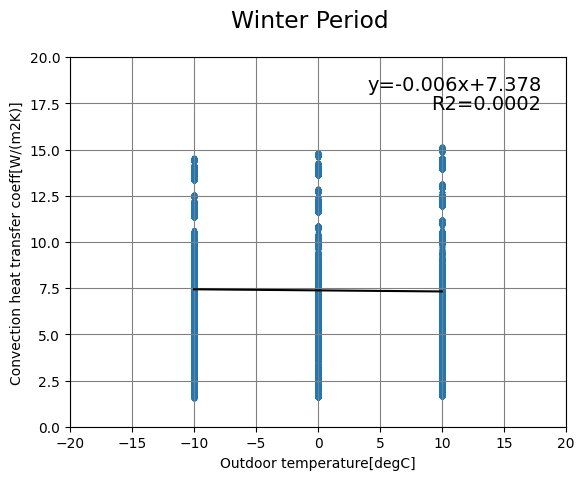

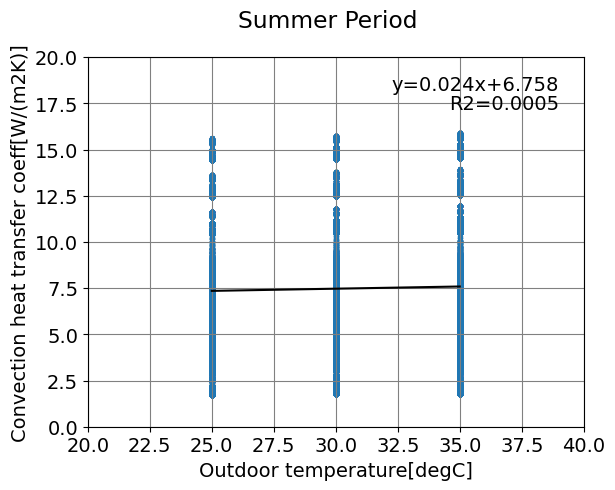

In [16]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Outdoor temperature[degC]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "theta_e",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -20.0,
       xlim_max = 20.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Outdoor temperature[degC]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "theta_e",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 20.0,
       xlim_max = 40.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 外気側表面に入射する日射量（j_surf）× 対流熱伝達率（h_cv）

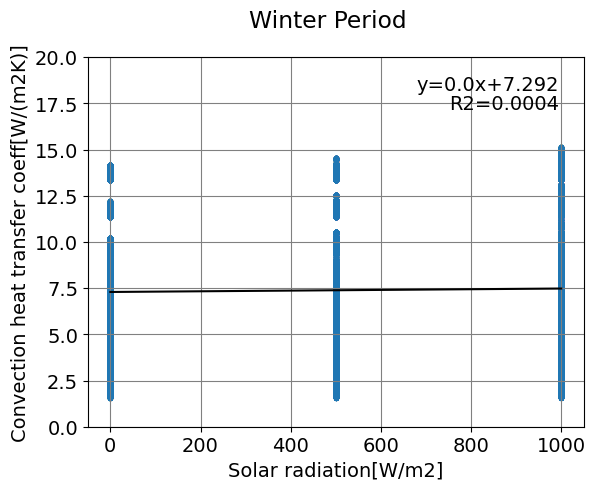

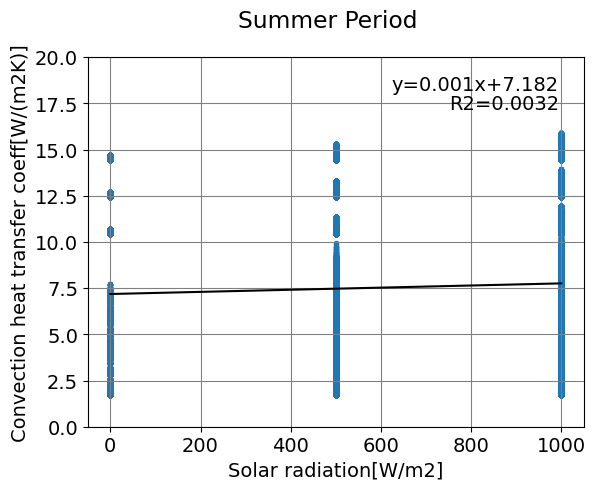

In [17]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Solar radiation[W/m2]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "j_surf",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -50.0,
       xlim_max = 1050.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Solar radiation[W/m2]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "j_surf",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -50.0,
       xlim_max = 1050.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 外気側表面日射吸収率（a_surf）× 対流熱伝達率（h_cv）

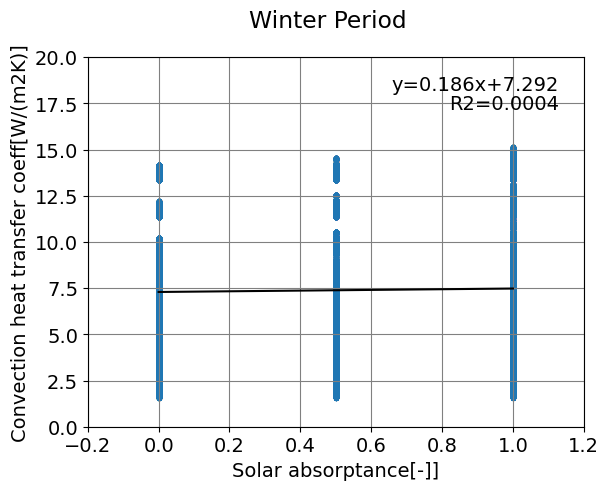

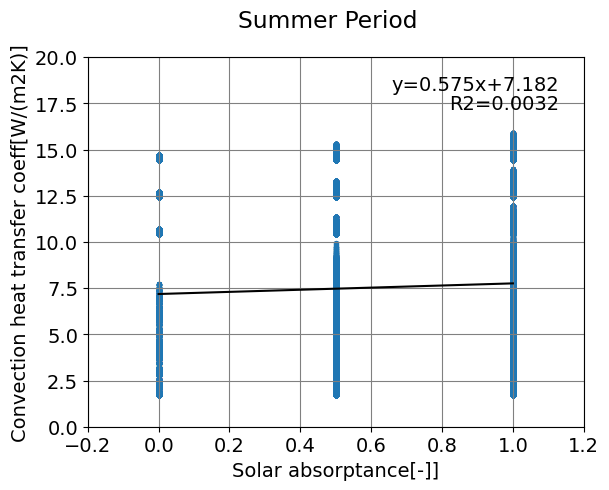

In [18]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Solar absorptance[-]]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "a_surf",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Solar absorptance[-]]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "a_surf",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 外気側部材の熱コンダクタンス（C_1）× 対流熱伝達率（h_cv）

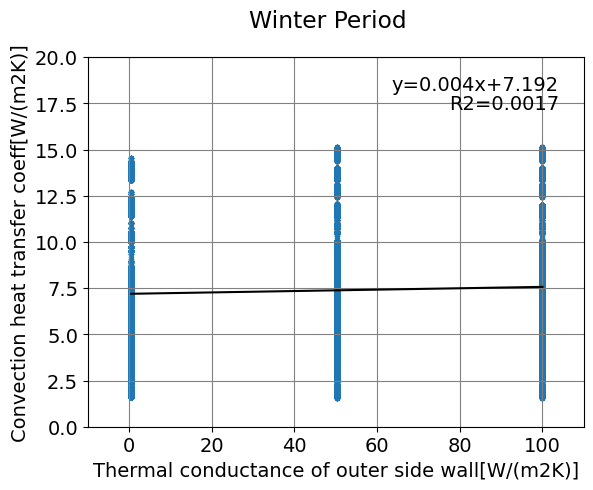

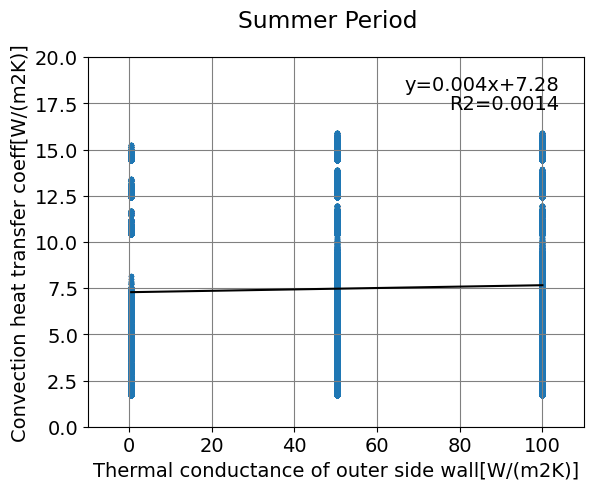

In [19]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Thermal conductance of outer side wall[W/(m2K)]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_1",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -10.0,
       xlim_max = 110.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Thermal conductance of outer side wall[W/(m2K)]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_1",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -10.0,
       xlim_max = 110.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 室内側部材の熱コンダクタンス（C_2）× 対流熱伝達率（h_cv）

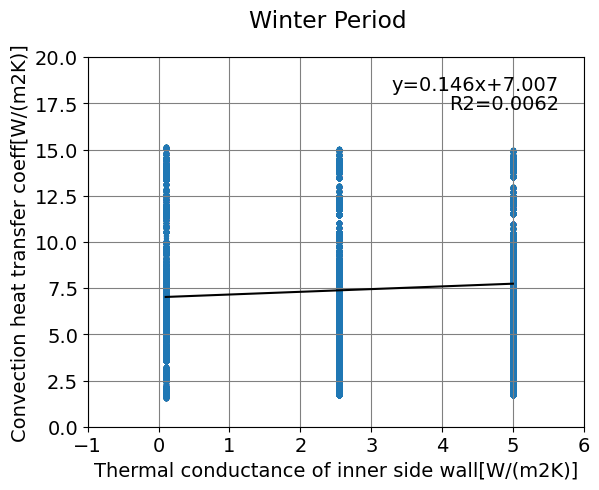

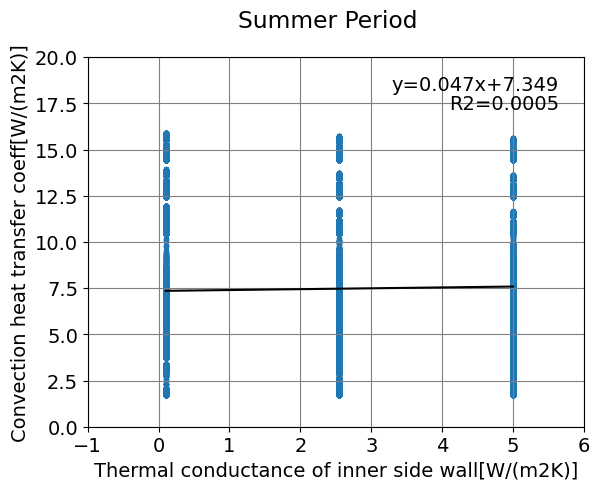

In [20]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Thermal conductance of inner side wall[W/(m2K)]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_2",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -1.0,
       xlim_max = 6.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Thermal conductance of inner side wall[W/(m2K)]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_2",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -1.0,
       xlim_max = 6.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層の長さ（l_h）× 対流熱伝達率（h_cv）

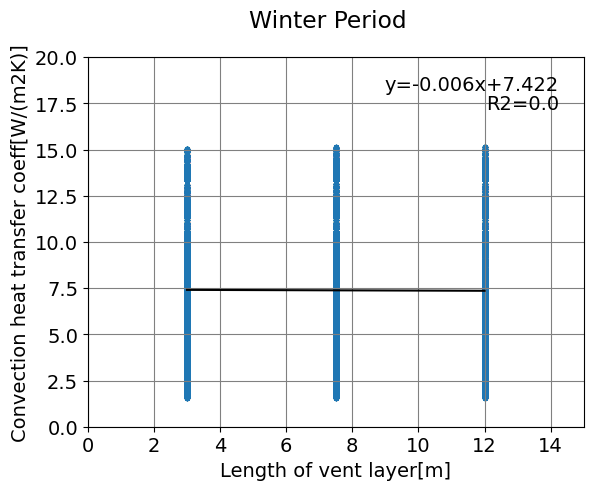

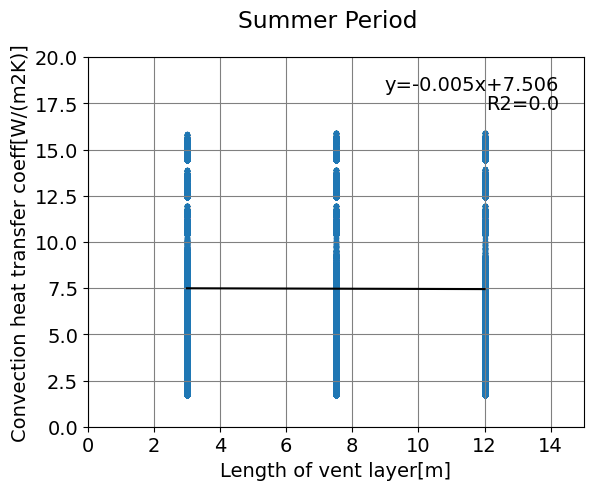

In [21]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Length of vent layer[m]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_h",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 15.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Length of vent layer[m]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_h",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 15.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層の厚さ（l_d）× 対流熱伝達率（h_cv）

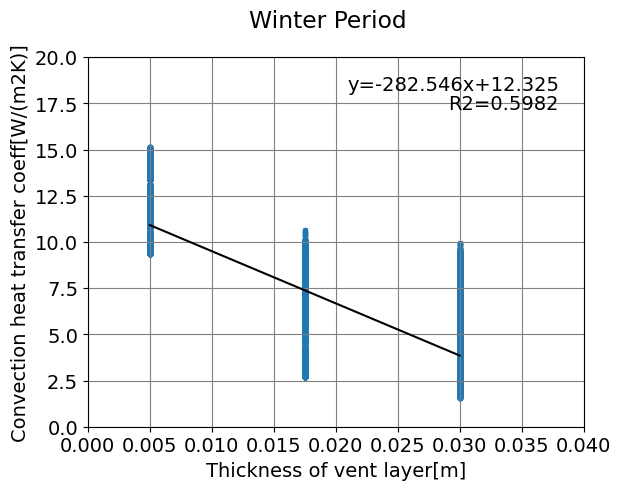

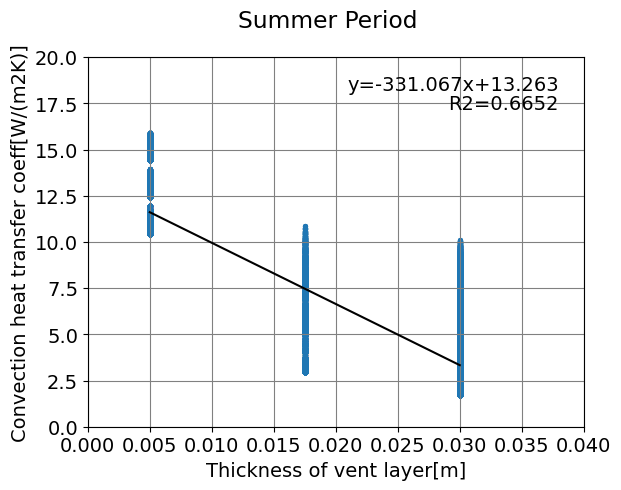

In [22]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Thickness of vent layer[m]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_d",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 0.04,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Thickness of vent layer[m]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_d",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 0.04,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層の傾斜角（angle）× 対流熱伝達率（h_cv）

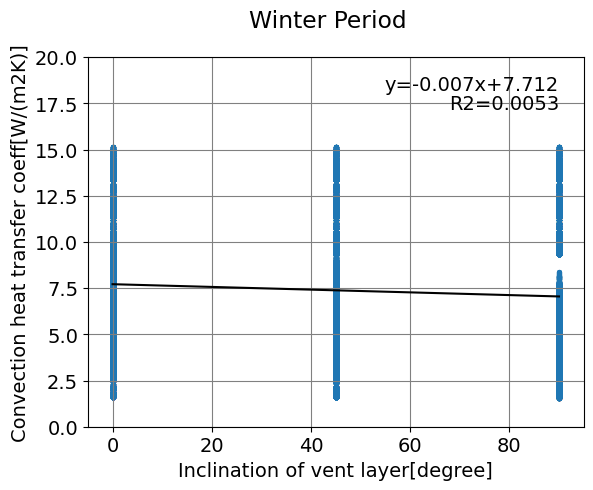

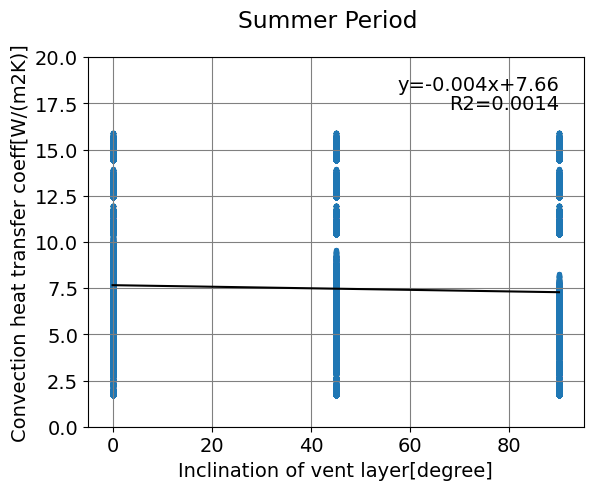

In [23]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Inclination of vent layer[degree]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Inclination of vent layer[degree]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層の平均風速（v_a）× 対流熱伝達率（h_cv）

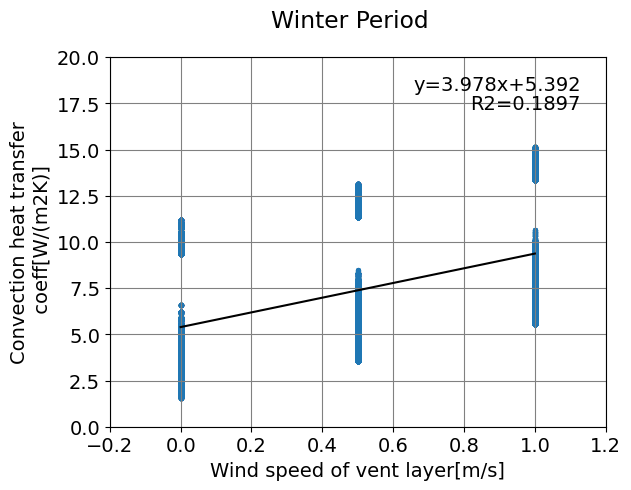

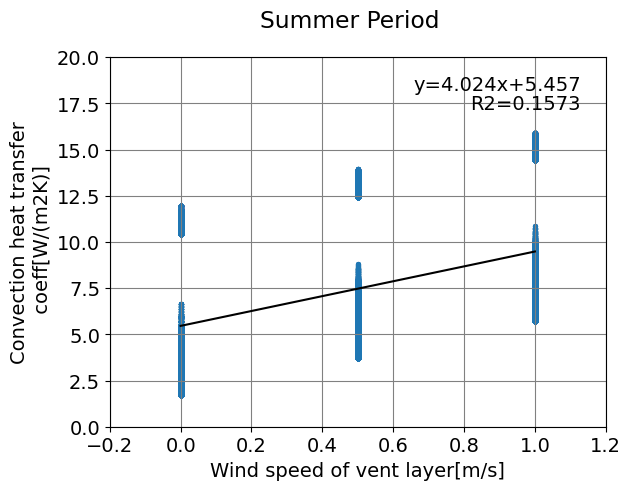

In [24]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

### 通気層に面する面2の放射率（emissivity_2）× 対流熱伝達率（h_cv）

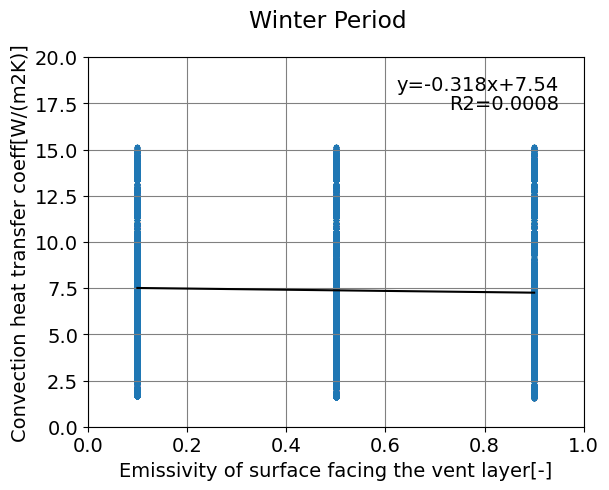

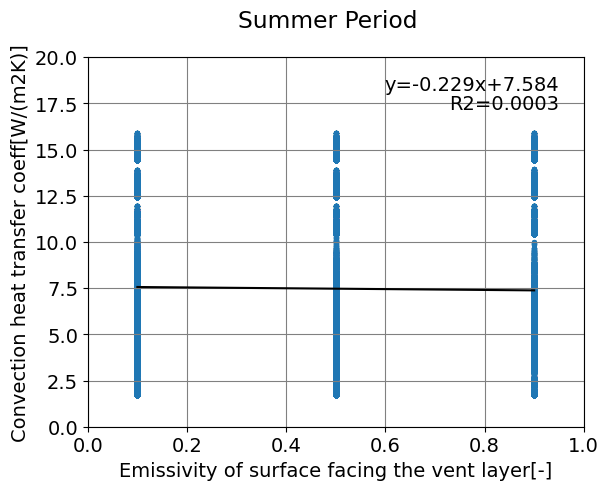

In [25]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Emissivity of surface facing the vent layer[-]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "emissivity_2",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 1.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Emissivity of surface facing the vent layer[-]",
       y_label = "Convection heat transfer coeff[W/(m2K)]", 
       x_data_name = "emissivity_2",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 1.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

対流熱伝達率に影響を与える要因は、通気層厚さと風速であることが見て取れる。通気層厚さは耐久性等の観点からあまり仕様にばらつきが少ないのに対し、通気層内の風速は季節や地域、日射の有無など外的要因によって大きく変動する。そのため、通気層内の風速を説明変数としてより詳細に解析する。

### 通気層内風速（詳細な解析）

通気層の厚さごとに整理する。

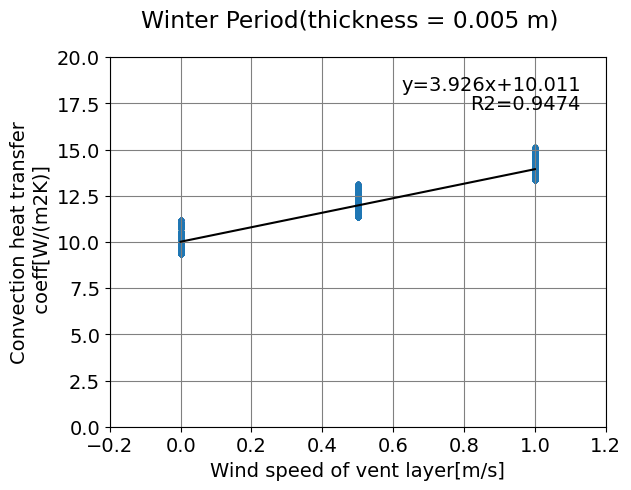

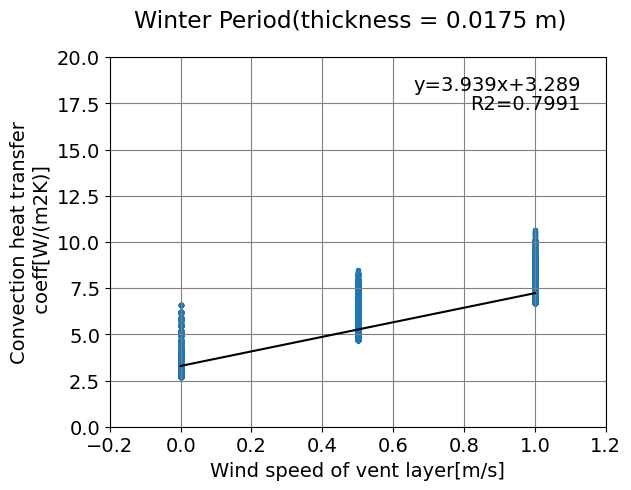

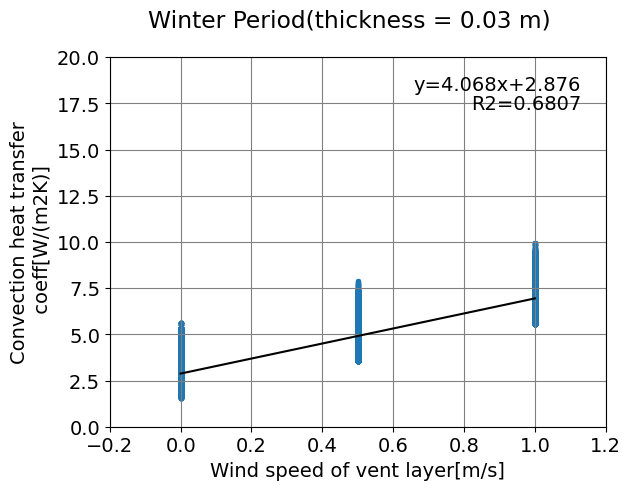

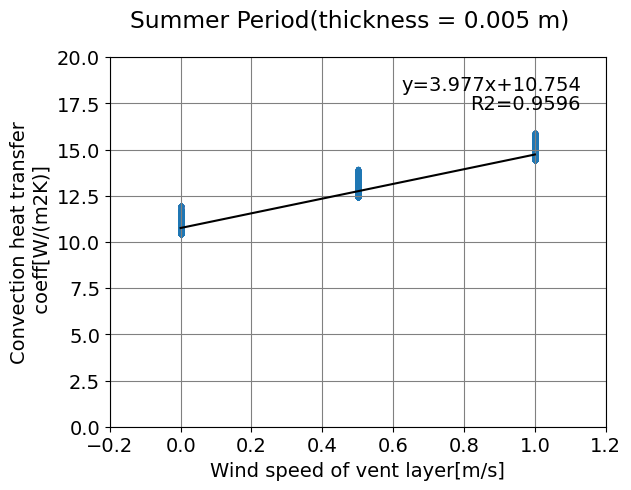

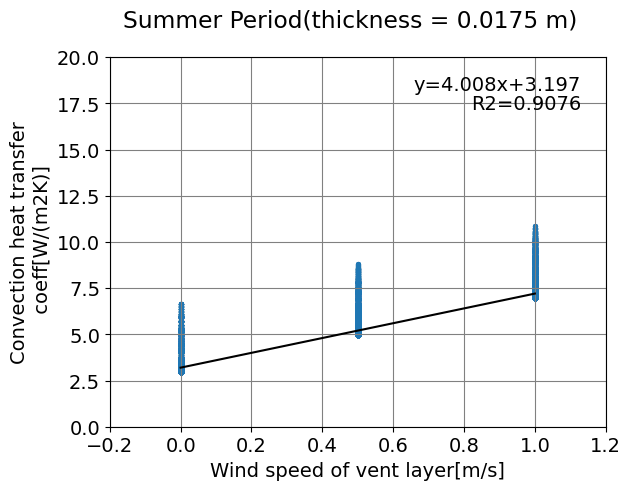

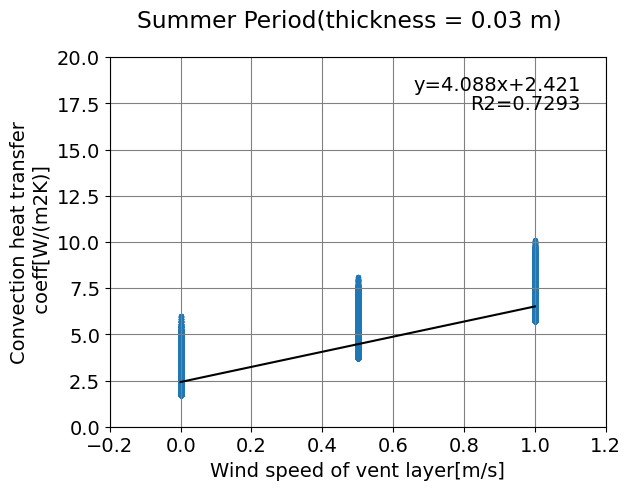

In [26]:
# 冬期条件
setPltSingle(df = df_winter.query('l_d == 0.005'),
       fig_title = "Winter Period(thickness = 0.005 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 冬期条件
setPltSingle(df = df_winter.query('l_d == 0.0175'),
       fig_title = "Winter Period(thickness = 0.0175 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 冬期条件
setPltSingle(df = df_winter.query('l_d == 0.03'),
       fig_title = "Winter Period(thickness = 0.03 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer.query('l_d == 0.005'),
       fig_title = "Summer Period(thickness = 0.005 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer.query('l_d == 0.0175'),
       fig_title = "Summer Period(thickness = 0.0175 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer.query('l_d == 0.03'),
       fig_title = "Summer Period(thickness = 0.03 m)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

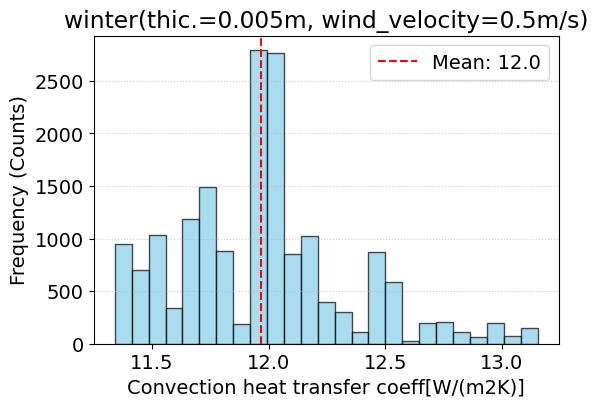

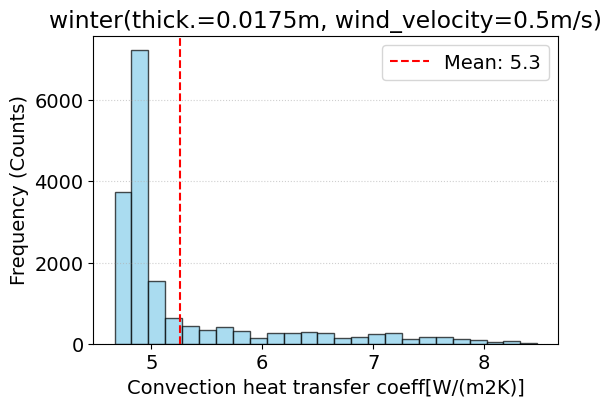

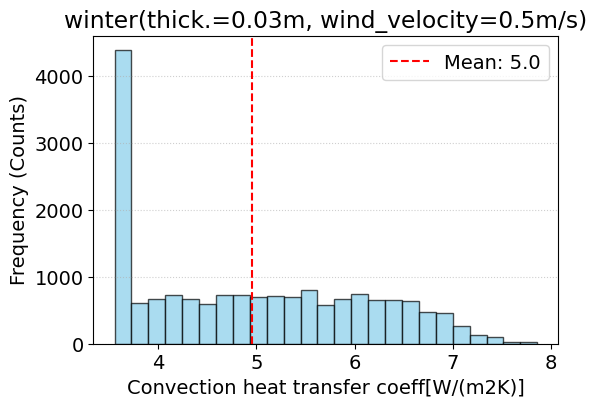

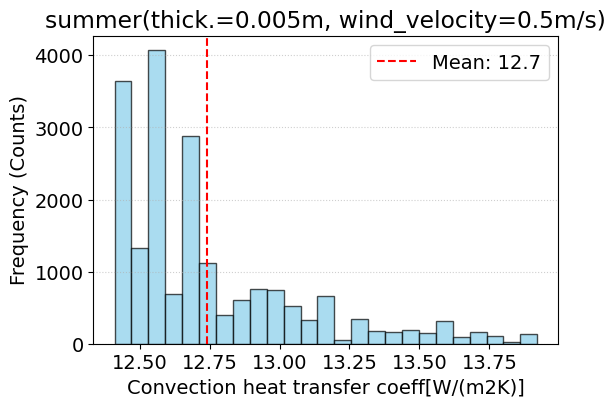

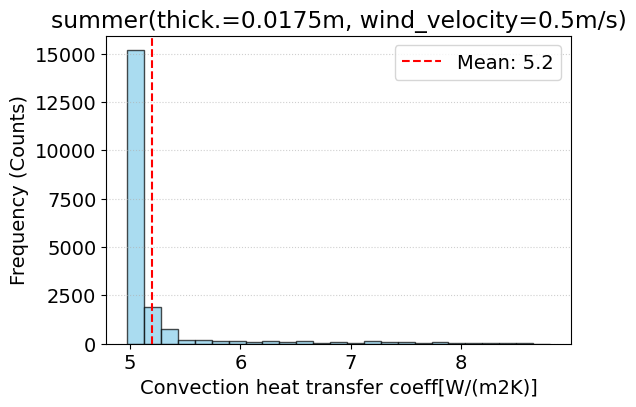

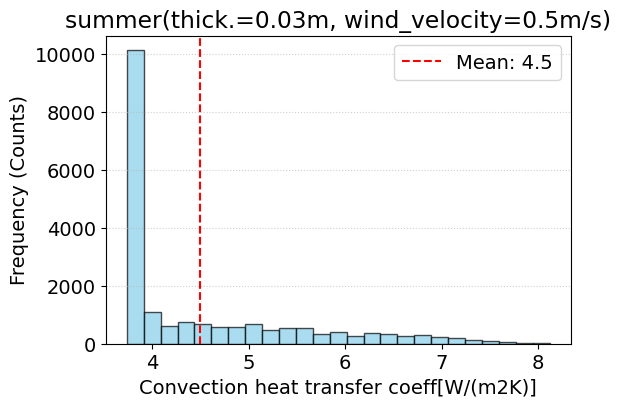

In [27]:
setHist(df=df_winter.query('l_d == 0.005 and v_a == 0.5'), fig_title='winter(thic.=0.005m, wind_velocity=0.5m/s)')
setHist(df=df_winter.query('l_d == 0.0175 and v_a == 0.5'), fig_title='winter(thick.=0.0175m, wind_velocity=0.5m/s)')
setHist(df=df_winter.query('l_d == 0.03 and v_a == 0.5'), fig_title='winter(thick.=0.03m, wind_velocity=0.5m/s)')
setHist(df=df_summer.query('l_d == 0.005 and v_a == 0.5'), fig_title='summer(thick.=0.005m, wind_velocity=0.5m/s)')
setHist(df=df_summer.query('l_d == 0.0175 and v_a == 0.5'), fig_title='summer(thick.=0.0175m, wind_velocity=0.5m/s)')
setHist(df=df_summer.query('l_d == 0.03 and v_a == 0.5'), fig_title='summer(thick.=0.03m, wind_velocity=0.5m/s)')

### 通気層内の角度の影響の確認

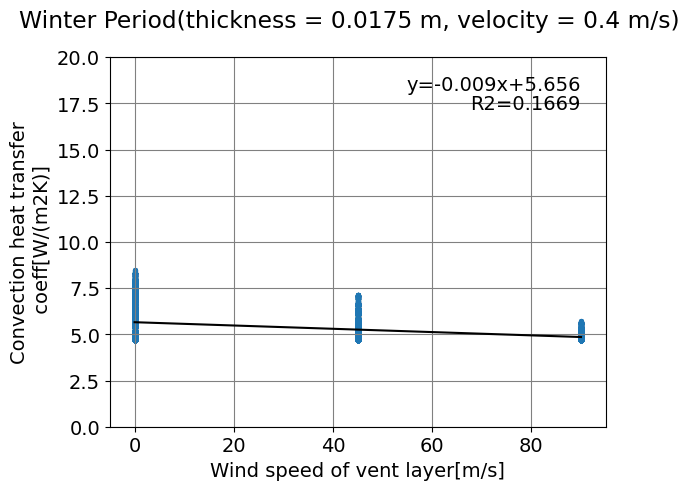

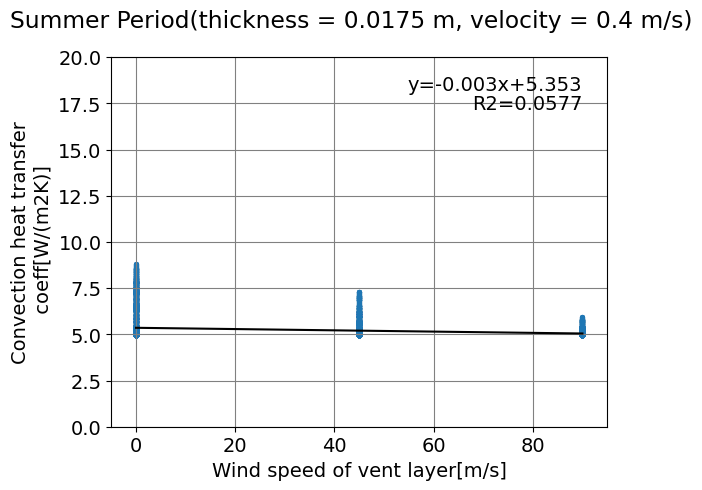

In [28]:
# 冬期条件
setPltSingle(df = df_winter.query('l_d == 0.0175 and v_a == 0.5'),
       fig_title = "Winter Period(thickness = 0.0175 m, velocity = 0.4 m/s)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 夏期条件
setPltSingle(df = df_summer.query('l_d == 0.0175 and v_a == 0.5'),
       fig_title = "Summer Period(thickness = 0.0175 m, velocity = 0.4 m/s)",
       x_label = "Wind speed of vent layer[m/s]",
       y_label = "Convection heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_cv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 20.0
      )

# 放射熱伝達率の近似式の作成

## 要約統計量

In [29]:
df_winter.loc[:,["h_rv"]].describe(), df_summer.loc[:,["h_rv"]].describe()

(                h_rv
 count  157464.000000
 mean        2.393644
 std         1.561135
 min         0.410069
 25%         0.535636
 50%         2.442024
 75%         3.809913
 max         6.246198,
                 h_rv
 count  177147.000000
 mean        3.096783
 std         2.002062
 min         0.594610
 25%         0.683108
 50%         3.073880
 75%         5.104434
 max         7.803264)

## 重回帰分析

冬期条件

In [30]:
# 最小二乗法による回帰モデルを作成
f = "h_rv ~ theta_e + j_surf + a_surf + C_1 + C_2 + l_h + l_w + l_d + angle + v_a + emissivity_2"
model_winter = ols(f, df_winter).fit()
model_winter.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   h_rv   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                 4.665e+05
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:24:49   Log-Likelihood:                -16889.
No. Observations:              157464   AIC:                         3.380e+04
Df Residuals:                  157452   BIC:                         3.392e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.2118      0.003    -68.487      0.000      -0.218      -0.206
theta_e          0.0196   8.08e-05    242.303      0.000       0.019       0.020
j_surf           0.0003   1.62e-06    194.248      0.000       0.000       0.000
a_surf           0.3137      0.002    194.248      0.000       0.311       0.317
C_1             -0.0002   1.67e-05     -9.733      0.000      -0.000      -0.000
C_2              0.0221      0.000     65.002      0.000       0.021       0.023
l_h              0.0045      0.000     24.244      0.000       0.004       0.005
l_w           4.682e-16      0.000    2.8e-12      1.000      -0.000       0.000
l_d             -1.9856      0.067    -29.853      0.000      -2.116      -1.855
angle         1.318e-05   1.85e-05      0.713      0.476    -2.3e-05    4.94e-05
v_a             -0.1111      0.002    -66.819      0.000      -0.114      -0.108
emissivity_2     4.6418      0.002   2233.236      0.000       4.638       4.646
==============================================================================
Omnibus:                    28070.492   Durbin-Watson:                   1.722
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            85498.062
Skew:                           0.929   Prob(JB):                         0.00
Kurtosis:                       6.095   Cond. No.                     6.27e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.27e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

夏期条件

In [31]:
# 最小二乗法による回帰モデルを作成
f = "h_rv ~ theta_e + j_surf + a_surf + C_1 + C_2 + l_h + l_w + l_d + angle + v_a + emissivity_2"
model_summer = ols(f, df_summer).fit()
model_summer.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   h_rv   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 7.465e+05
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        09:24:49   Log-Likelihood:                -32636.
No. Observations:              177147   AIC:                         6.530e+04
Df Residuals:                  177135   BIC:                         6.542e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.0100      0.006   -168.573      0.000      -1.022      -0.998
theta_e          0.0233      0.000    137.736      0.000       0.023       0.024
j_surf           0.0004   1.69e-06    224.125      0.000       0.000       0.000
a_surf           0.3795      0.002    224.125      0.000       0.376       0.383
C_1              0.0020    1.7e-05    119.920      0.000       0.002       0.002
C_2             -0.0212      0.000    -61.225      0.000      -0.022      -0.020
l_h              0.0022      0.000     11.688      0.000       0.002       0.003
l_w           3.229e-17      0.000    1.9e-13      1.000      -0.000       0.000
l_d             -1.1636      0.068    -17.181      0.000      -1.296      -1.031
angle        -7.449e-06   1.88e-05     -0.396      0.692   -4.43e-05    2.94e-05
v_a             -0.0469      0.002    -27.676      0.000      -0.050      -0.044
emissivity_2     6.0135      0.002   2841.316      0.000       6.009       6.018
==============================================================================
Omnibus:                    52416.777   Durbin-Watson:                   1.638
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           209456.194
Skew:                           1.428   Prob(JB):                         0.00
Kurtosis:                       7.496   Cond. No.                     6.35e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.35e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 散布図による検証

### 外気温度（theta_e）× 放射熱伝達率（h_rv）

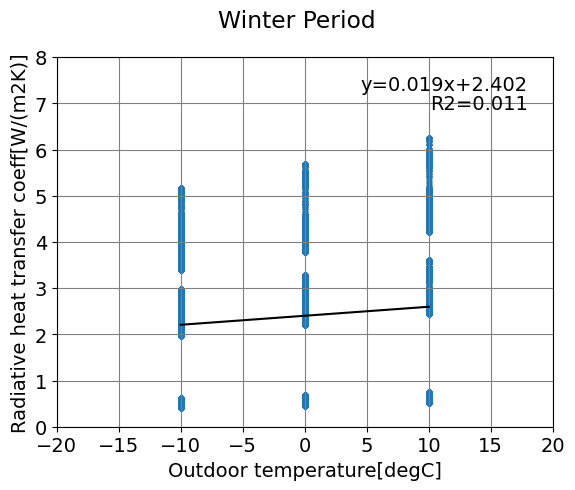

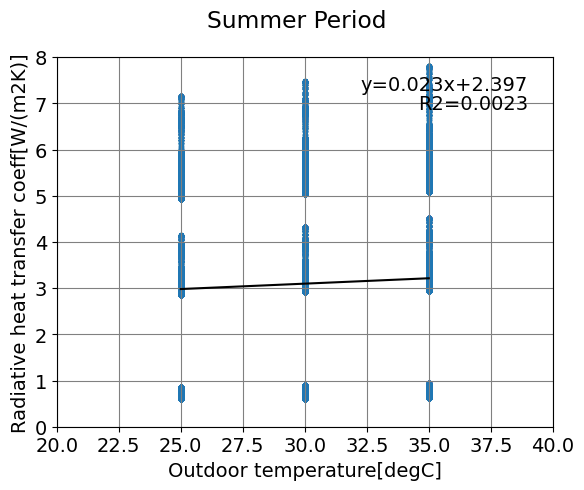

In [32]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Outdoor temperature[degC]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "theta_e",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -20.0,
       xlim_max = 20.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Outdoor temperature[degC]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "theta_e",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = 20.0,
       xlim_max = 40.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 外気側表面に入射する日射量（j_surf）× 放射熱伝達率（h_rv）

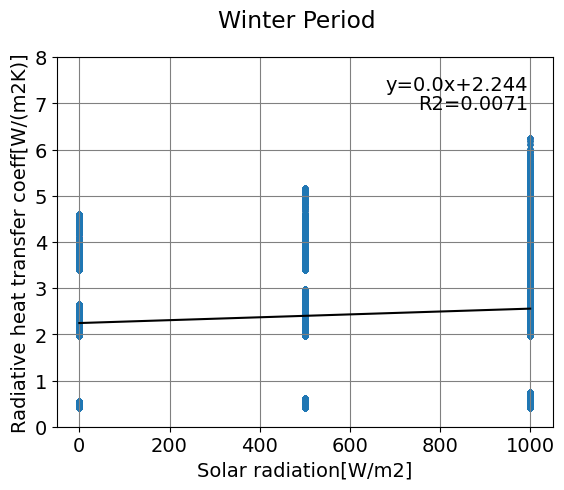

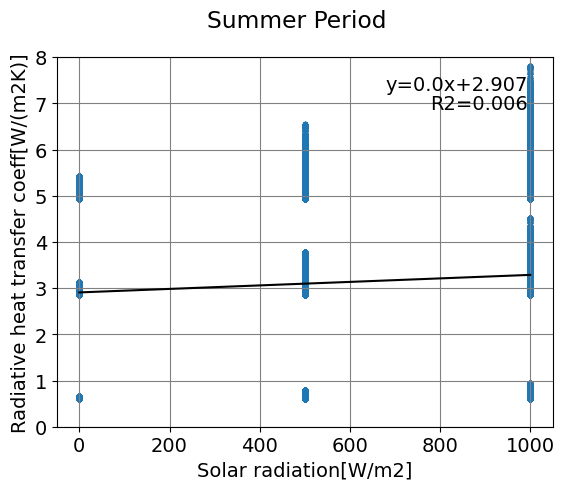

In [33]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Solar radiation[W/m2]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "j_surf",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -50.0,
       xlim_max = 1050.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Solar radiation[W/m2]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "j_surf",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -50.0,
       xlim_max = 1050.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 外気側表面日射吸収率（a_surf）× 放射熱伝達率（h_rv）

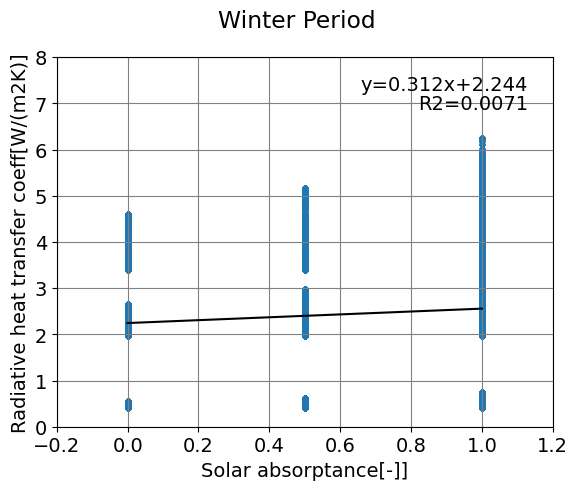

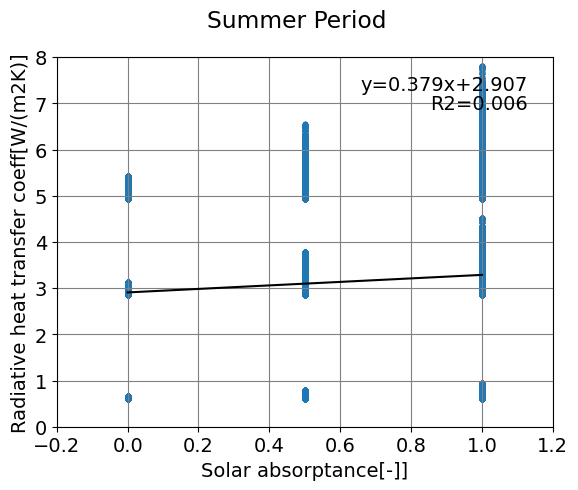

In [34]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Solar absorptance[-]]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "a_surf",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Solar absorptance[-]]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "a_surf",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 外気側部材の熱コンダクタンス（C_1）× 放射熱伝達率（h_rv）

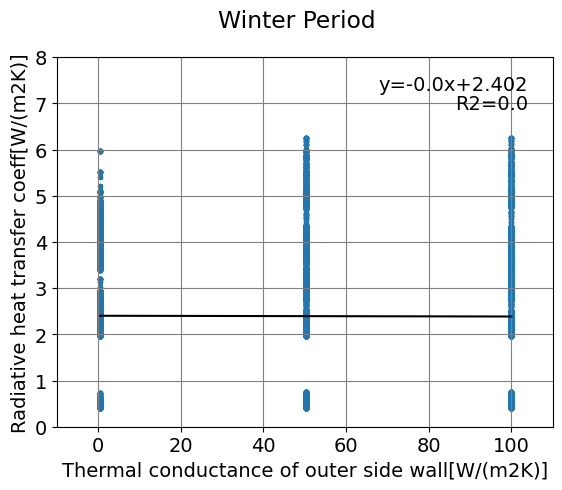

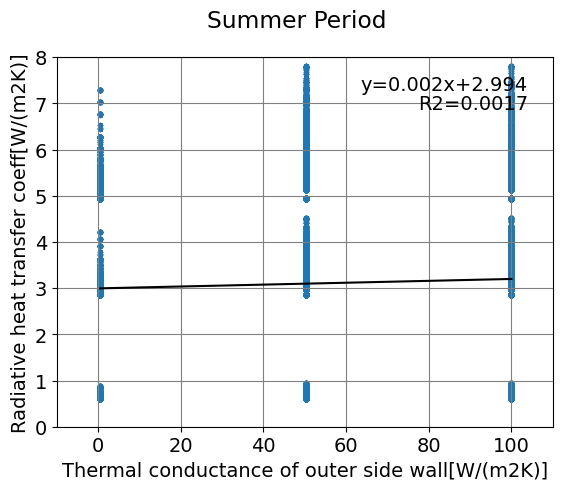

In [35]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Thermal conductance of outer side wall[W/(m2K)]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_1",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -10.0,
       xlim_max = 110.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Thermal conductance of outer side wall[W/(m2K)]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_1",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -10.0,
       xlim_max = 110.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 室内側部材の熱コンダクタンス（C_2）× 放射熱伝達率（h_rv）

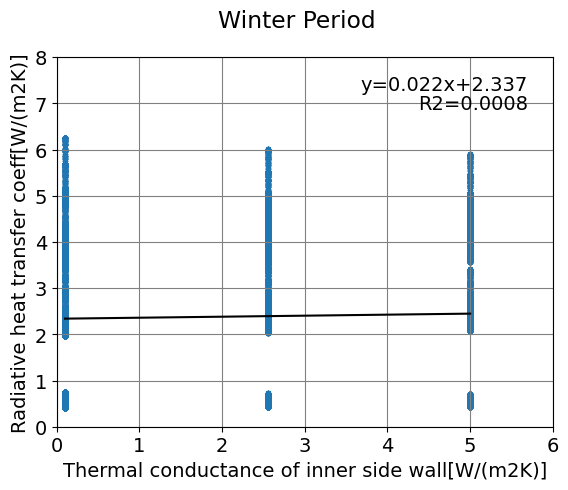

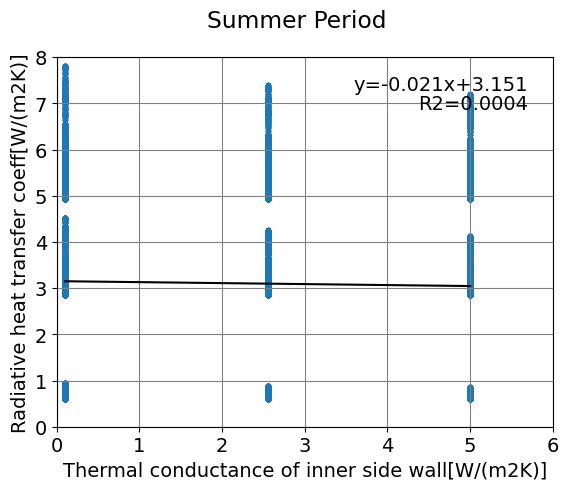

In [36]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Thermal conductance of inner side wall[W/(m2K)]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_2",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 6.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Thermal conductance of inner side wall[W/(m2K)]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "C_2",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 6.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 通気層の長さ（l_h）× 放射熱伝達率（h_rv）

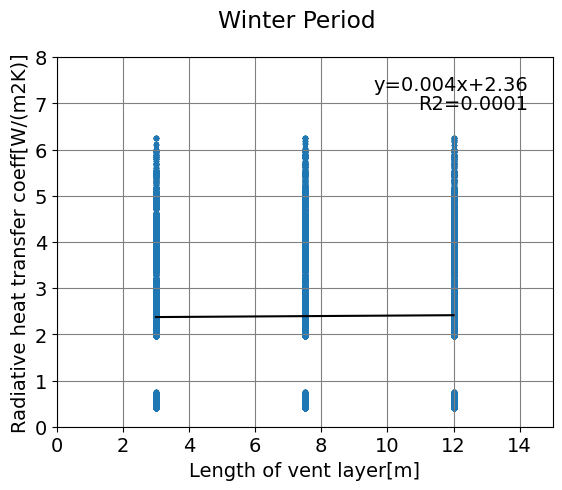

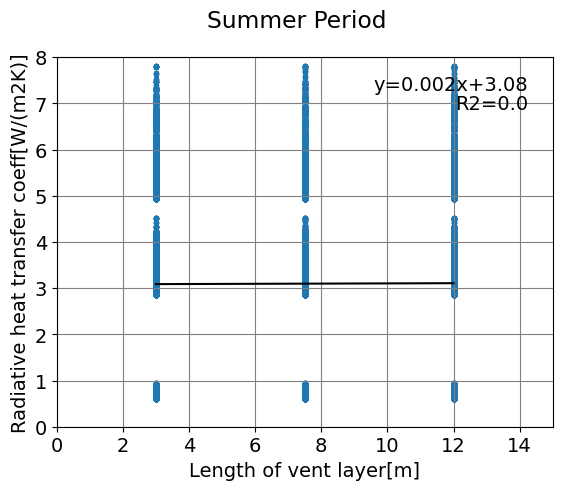

In [37]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Length of vent layer[m]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_h",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 15.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Length of vent layer[m]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_h",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 15.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 通気層の厚さ（l_d）× 放射熱伝達率（h_rv）

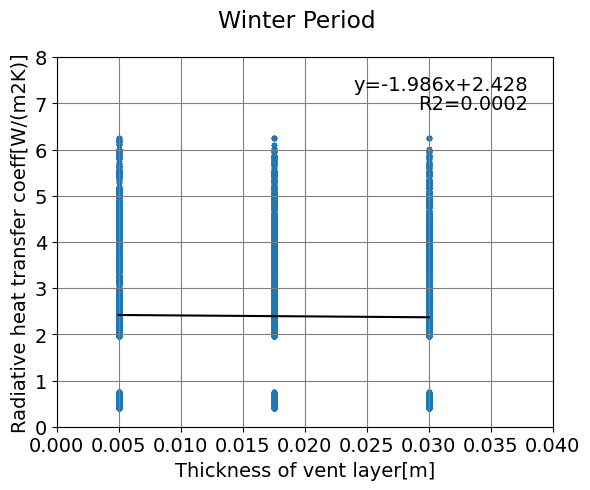

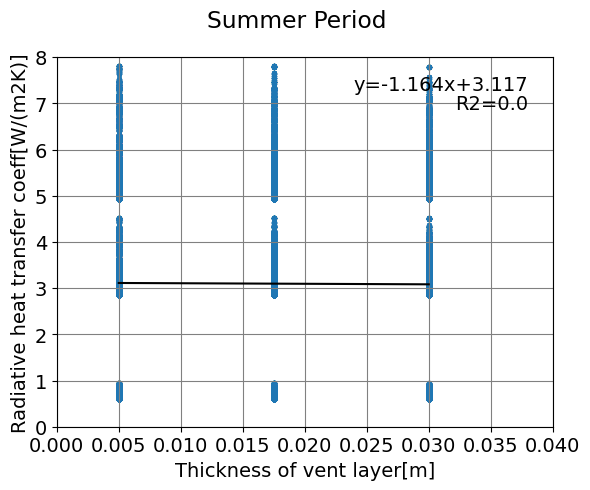

In [38]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Thickness of vent layer[m]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_d",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 0.04,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Thickness of vent layer[m]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "l_d",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 0.04,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 通気層の傾斜角（angle）× 放射熱伝達率（h_rv）

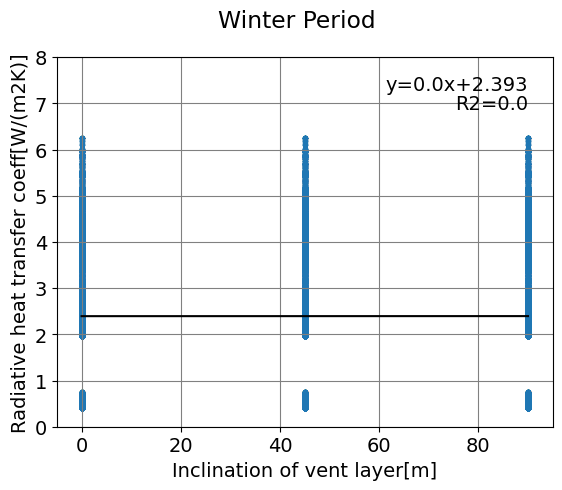

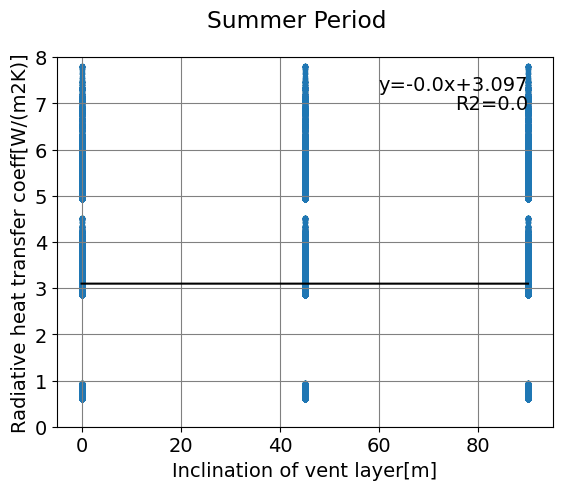

In [39]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Inclination of vent layer[m]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Inclination of vent layer[m]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "angle",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -5.0,
       xlim_max = 95.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 通気層の平均風速（v_a）× 放射熱伝達率（h_rv）

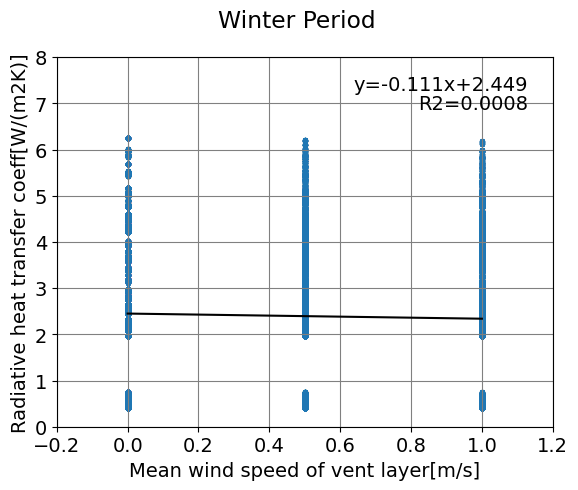

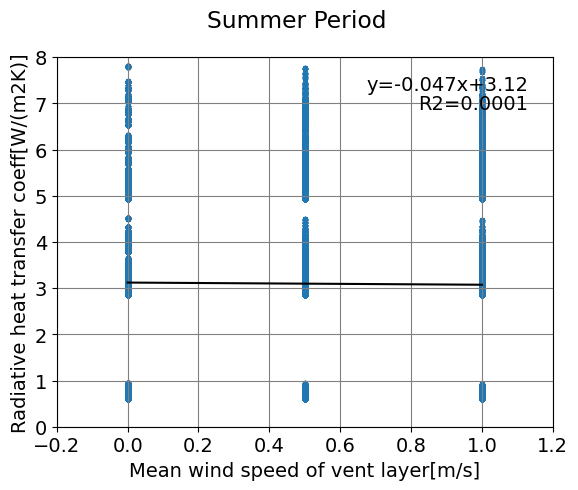

In [40]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Mean wind speed of vent layer[m/s]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Mean wind speed of vent layer[m/s]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "v_a",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = -0.2,
       xlim_max = 1.2,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 通気層に面する面2の放射率（emissivity_2）× 放射熱伝達率（h_rv）

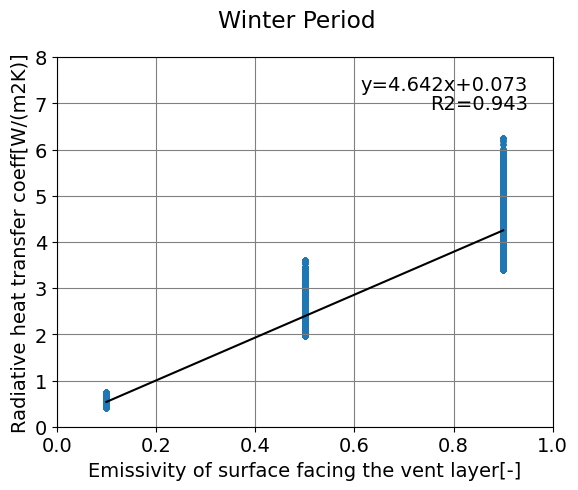

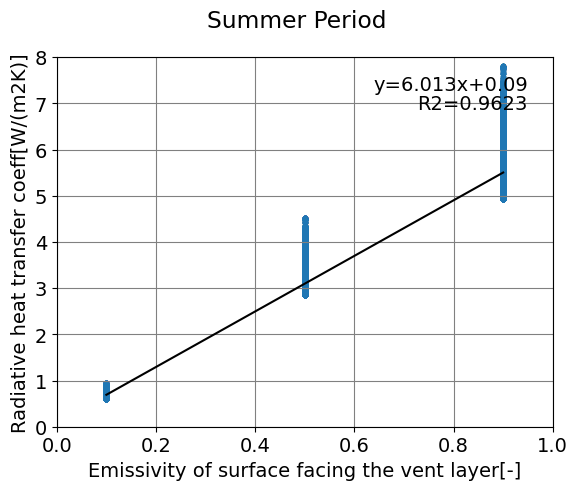

In [41]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Emissivity of surface facing the vent layer[-]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "emissivity_2",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 1.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Emissivity of surface facing the vent layer[-]",
       y_label = "Radiative heat transfer coeff[W/(m2K)]", 
       x_data_name = "emissivity_2",
       y_data_name = "h_rv",
       is_fit_intercept = True,
       xlim_min = 0.0,
       xlim_max = 1.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

### 通気層面の有効放射率（effective_emissivity）× 放射熱伝達率（h_rv）

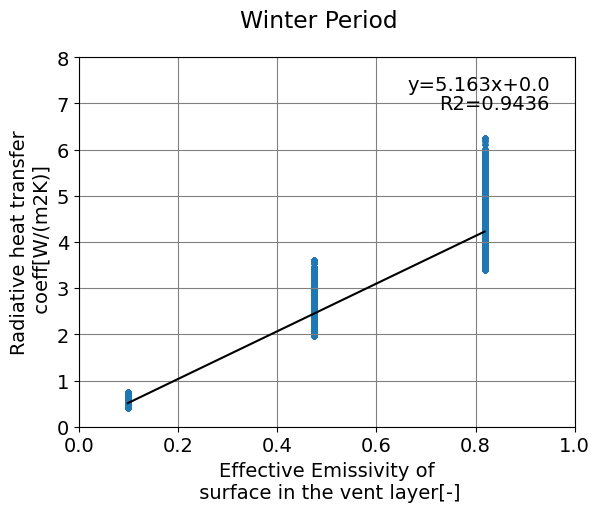

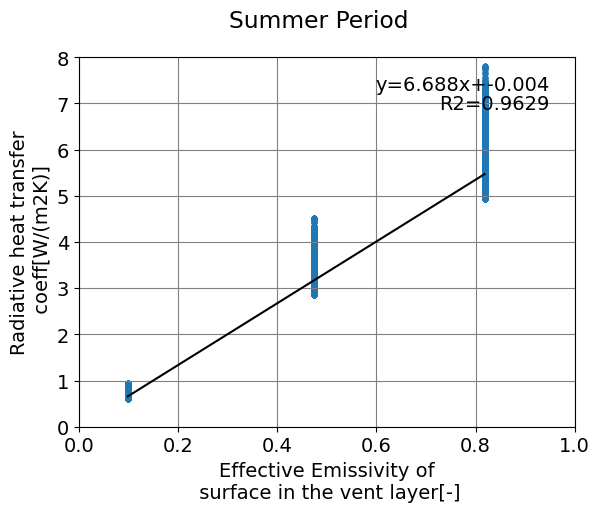

In [42]:
# 冬期条件
setPltSingle(df = df_winter,
       fig_title = "Winter Period",
       x_label = "Effective Emissivity of\n surface in the vent layer[-]",
       y_label = "Radiative heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "effective_emissivity",
       y_data_name = "h_rv",
       is_fit_intercept = False,
       xlim_min = 0.0,
       xlim_max = 1.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 夏期条件
setPltSingle(df = df_summer,
       fig_title = "Summer Period",
       x_label = "Effective Emissivity of\n surface in the vent layer[-]",
       y_label = "Radiative heat transfer\n coeff[W/(m2K)]", 
       x_data_name = "effective_emissivity",
       y_data_name = "h_rv",
       is_fit_intercept = False,
       xlim_min = 0.0,
       xlim_max = 1.0,
       ylim_min = 0.0,
       ylim_max = 8.0
      )

# 簡易化の検証（詳細計算との比較）

## 対流熱伝達率

### 厚さ0.005m（冬期）

In [43]:
df_winter_simple_C_005 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[-10.0, 0.0, 10.0], l_d=[0.005]),
        hcv_mode=HCVModeSimple(a=3.926, b=10.011),
        hrv_mode=HRVModeDetail()
    )
)
df_winter_detail_C_005 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[-10.0, 0.0, 10.0], l_d=[0.005]),
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeDetail()
    )
)

0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 52488
0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 52488


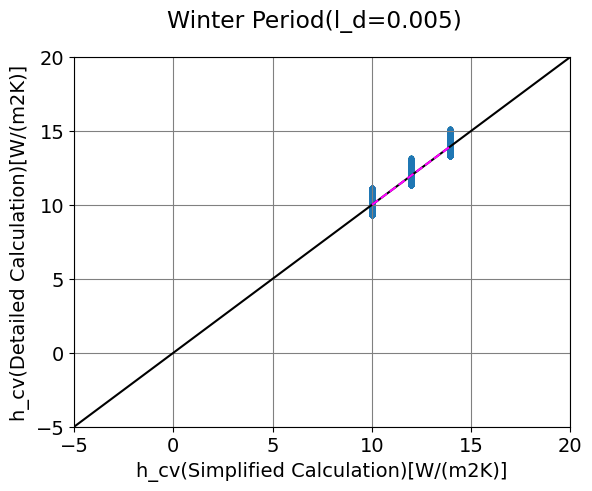

In [44]:
setPltComparison(
    fig_title = "Winter Period(l_d=0.005)",
    x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
    y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
    x_data = df_winter_simple_C_005["h_cv"],
    y_data = df_winter_detail_C_005["h_cv"],
    xlim_min = -5.0,
    xlim_max = 20.0,
    ylim_min = -5.0,
    ylim_max = 20.0
)

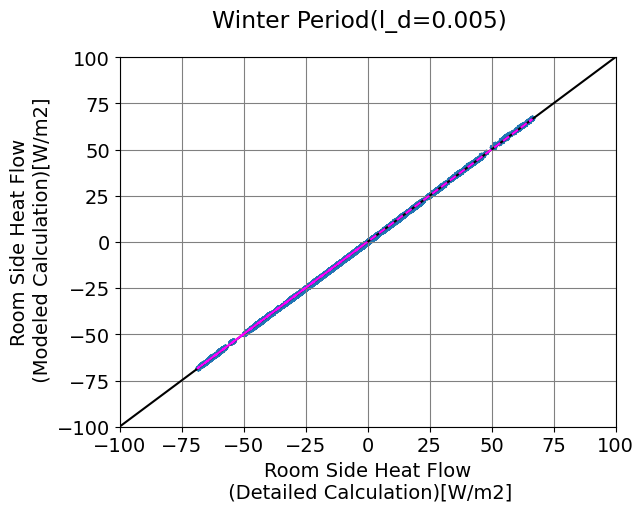

In [45]:
setPltComparison(
       fig_title = "Winter Period(l_d=0.005)",       
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_winter_simple_C_005["q_room_side"],
       y_data = df_winter_detail_C_005["q_room_side"],
       xlim_min = -100.0,
       xlim_max = 100.0,
       ylim_min = -100.0,
       ylim_max = 100.0
      )

### 厚さ0.005m（夏期）

In [46]:

df_summer_simple_C_005 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[25.0, 30.0, 35.0], l_d=[0.005]),
        hcv_mode=HCVModeSimple(a=3.977, b=10.754),
        hrv_mode=HRVModeDetail()
    )
)
df_summer_detail_C_005 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[25.0, 30.0, 35.0], l_d=[0.005]),
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeDetail()
    )
)


0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 59049
0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 59049


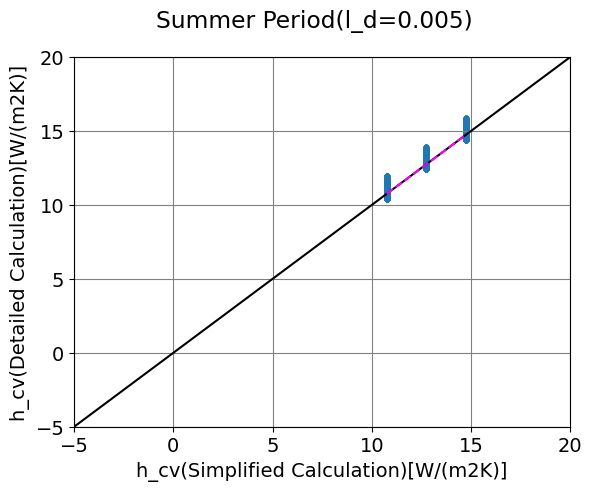

In [47]:
setPltComparison(
       fig_title = "Summer Period(l_d=0.005)",
       x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
       y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
       x_data = df_summer_simple_C_005["h_cv"],
       y_data = df_summer_detail_C_005["h_cv"],
       xlim_min = -5.0,
       xlim_max = 20.0,
       ylim_min = -5.0,
       ylim_max = 20.0
      )

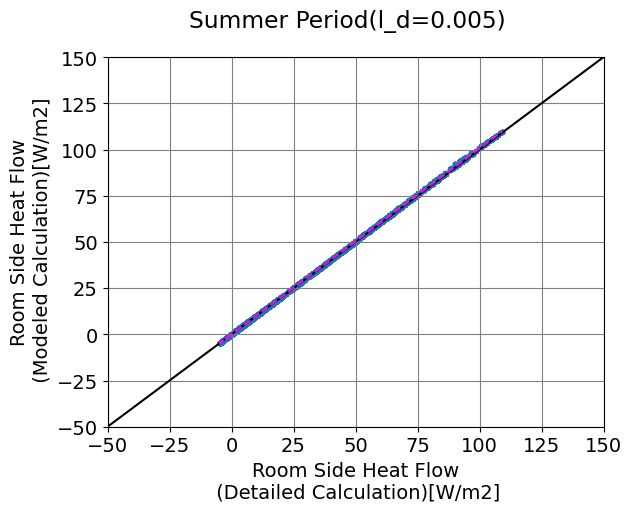

In [48]:
setPltComparison(
       fig_title = "Summer Period(l_d=0.005)",       
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_summer_simple_C_005["q_room_side"],
       y_data = df_summer_detail_C_005["q_room_side"],
       xlim_min = -50.0,
       xlim_max = 150.0,
       ylim_min = -50.0,
       ylim_max = 150.0
      )

### 厚さ0.0175m（冬期）

In [49]:
df_winter_simple_C_0175 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[-10.0, 0.0, 10.0], l_d=[0.0175]),
        hcv_mode=HCVModeSimple(a=3.939, b=3.289),
        hrv_mode=HRVModeDetail()
    )
)
df_winter_detail_C_0175 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[-10.0, 0.0, 10.0], l_d=[0.0175]),
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeDetail()
    )
)

0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 52488
0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 52488


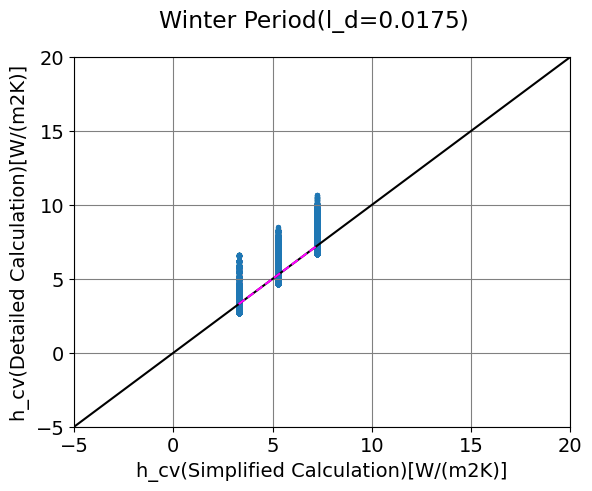

In [50]:
setPltComparison(
    fig_title = "Winter Period(l_d=0.0175)",
    x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
    y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
    x_data = df_winter_simple_C_0175["h_cv"],
    y_data = df_winter_detail_C_0175["h_cv"],
    xlim_min = -5.0,
    xlim_max = 20.0,
    ylim_min = -5.0,
    ylim_max = 20.0
)

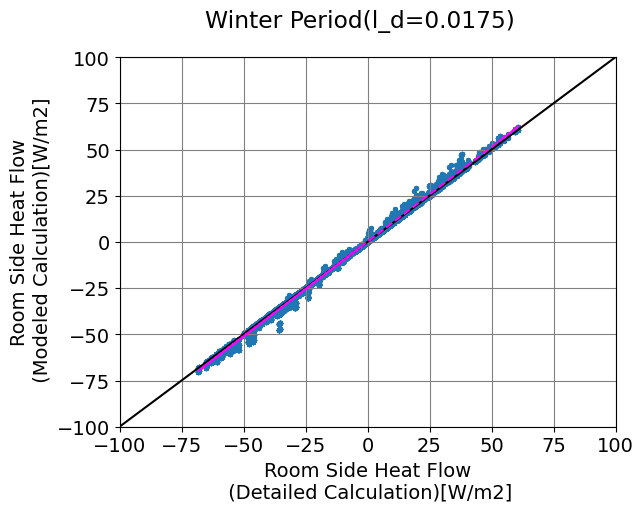

In [51]:
setPltComparison(
       fig_title = "Winter Period(l_d=0.0175)",       
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_winter_simple_C_0175["q_room_side"],
       y_data = df_winter_detail_C_0175["q_room_side"],
       xlim_min = -100.0,
       xlim_max = 100.0,
       ylim_min = -100.0,
       ylim_max = 100.0
      )

### 厚さ0.0175m（夏期）

In [52]:

df_summer_simple_C_0175 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[25.0, 30.0, 35.0], l_d=[0.0175]),
        hcv_mode=HCVModeSimple(a=4.008, b=3.197),
        hrv_mode=HRVModeDetail()
    )
)
df_summer_detail_C_0175 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[25.0, 30.0, 35.0], l_d=[0.0175]),
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeDetail()
    )
)

0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 59049
0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 59049


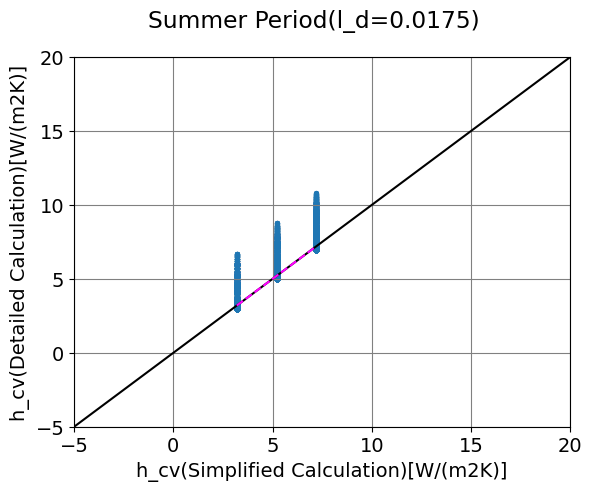

In [53]:
setPltComparison(
       fig_title = "Summer Period(l_d=0.0175)",
       x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
       y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
       x_data = df_summer_simple_C_0175["h_cv"],
       y_data = df_summer_detail_C_0175["h_cv"],
       xlim_min = -5.0,
       xlim_max = 20.0,
       ylim_min = -5.0,
       ylim_max = 20.0
      )

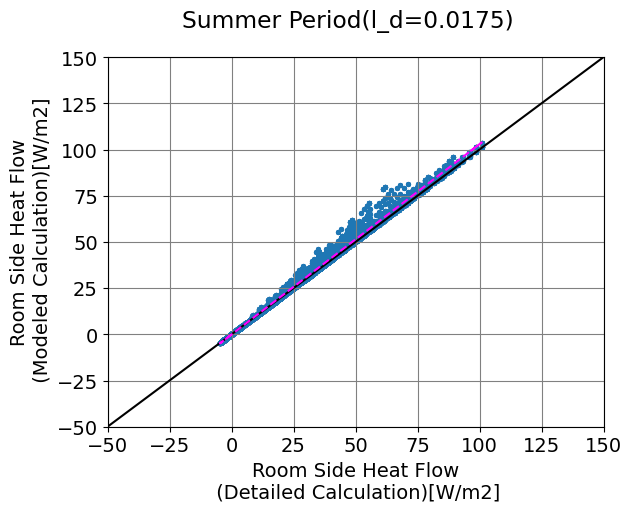

In [54]:
setPltComparison(
       fig_title = "Summer Period(l_d=0.0175)",       
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_summer_simple_C_0175["q_room_side"],
       y_data = df_summer_detail_C_0175["q_room_side"],
       xlim_min = -50.0,
       xlim_max = 150.0,
       ylim_min = -50.0,
       ylim_max = 150.0
      )

### 厚さ0.03m（冬期）

In [55]:
df_winter_simple_C_03 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[-10.0, 0.0, 10.0], l_d=[0.03]),
        hcv_mode=HCVModeSimple(a=4.068, b=2.876),
        hrv_mode=HRVModeDetail()
    )
)
df_winter_detail_C_03 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[-10.0, 0.0, 10.0], l_d=[0.03]),
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeDetail()
    )
)

0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 52488
0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 52488


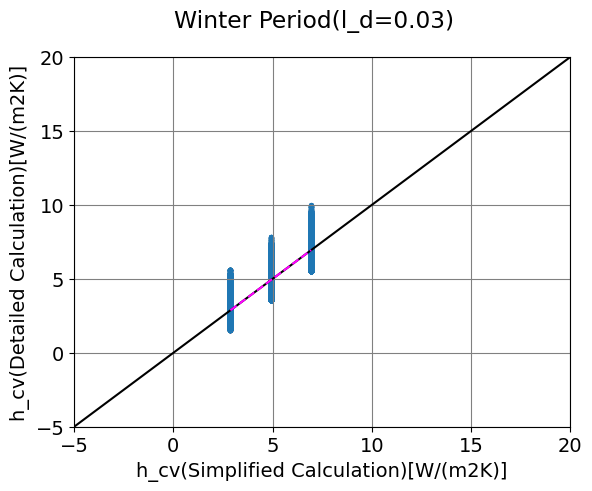

In [56]:
setPltComparison(
    fig_title = "Winter Period(l_d=0.03)",
    x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
    y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
    x_data = df_winter_simple_C_03["h_cv"],
    y_data = df_winter_detail_C_03["h_cv"],
    xlim_min = -5.0,
    xlim_max = 20.0,
    ylim_min = -5.0,
    ylim_max = 20.0
)

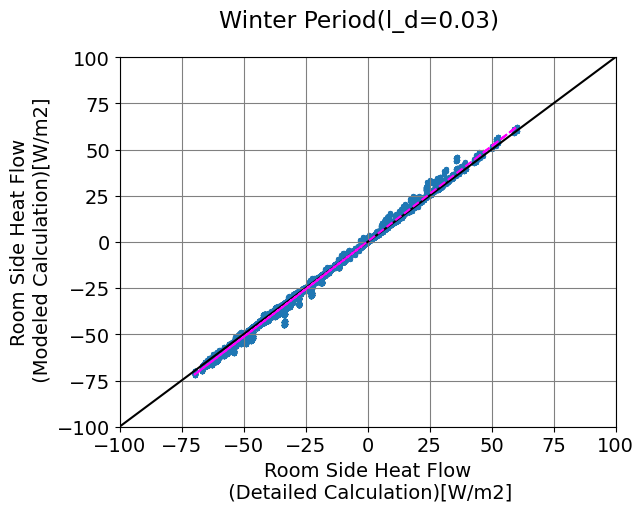

In [57]:
setPltComparison(
       fig_title = "Winter Period(l_d=0.03)",       
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_winter_simple_C_03["q_room_side"],
       y_data = df_winter_detail_C_03["q_room_side"],
       xlim_min = -100.0,
       xlim_max = 100.0,
       ylim_min = -100.0,
       ylim_max = 100.0
      )

### 厚さ0.03m（夏期）

In [58]:
df_summer_simple_C_03 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[25.0, 30.0, 35.0], l_d=[0.03]),
        hcv_mode=HCVModeSimple(a=4.008, b=2.421),
        hrv_mode=HRVModeDetail()
    )
)
df_summer_detail_C_03 = cleansing(
    df = vwp.get_wall_status_data_by_detailed_calculation(
        pms=pm.ParametersOptions.SetParameters(theta_e=[25.0, 30.0, 35.0], l_d=[0.03]),
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeDetail()
    )
)

0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 59049
0
10000
20000
30000
40000
50000
元データの数： 59049
収束しなかったデータを削除した後のデータ数： 59049
1つでも欠損地NaNがある行を削除した後のデータ数： 59049


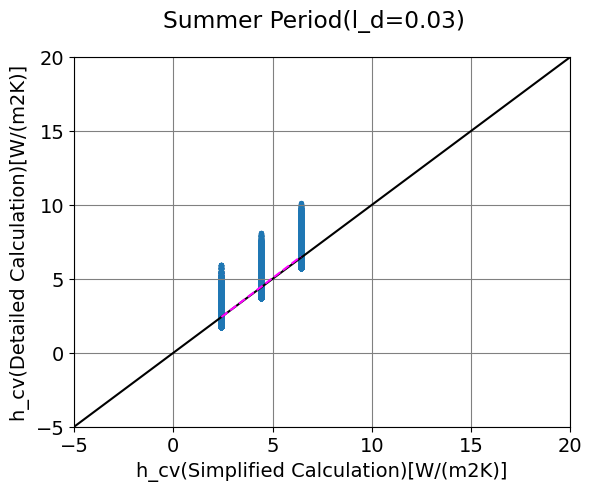

In [59]:
setPltComparison(
       fig_title = "Summer Period(l_d=0.03)",
       x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
       y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
       x_data = df_summer_simple_C_03["h_cv"],
       y_data = df_summer_detail_C_03["h_cv"],
       xlim_min = -5.0,
       xlim_max = 20.0,
       ylim_min = -5.0,
       ylim_max = 20.0
      )

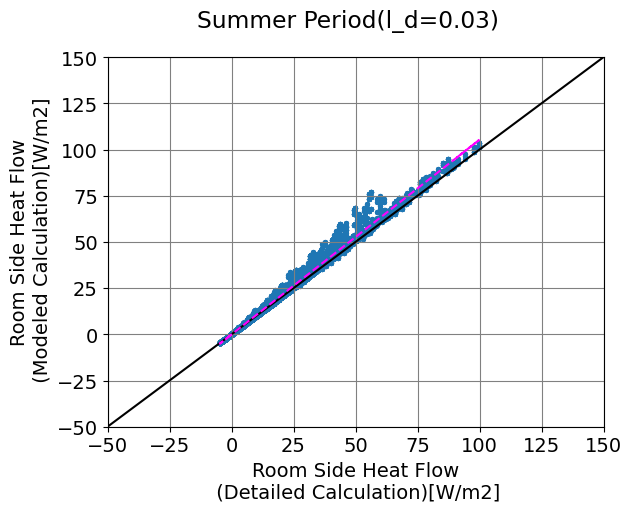

In [60]:
setPltComparison(
       fig_title = "Summer Period(l_d=0.03)",       
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_summer_simple_C_03["q_room_side"],
       y_data = df_summer_detail_C_03["q_room_side"],
       xlim_min = -50.0,
       xlim_max = 150.0,
       ylim_min = -50.0,
       ylim_max = 150.0
      )

### 全ての厚さ（冬期）

In [61]:
df_winter_simple_C = pd.concat([df_winter_simple_C_005, df_winter_simple_C_0175, df_winter_simple_C_03])
df_winter_detail_C = pd.concat([df_winter_detail_C_005, df_winter_detail_C_0175, df_winter_detail_C_03])

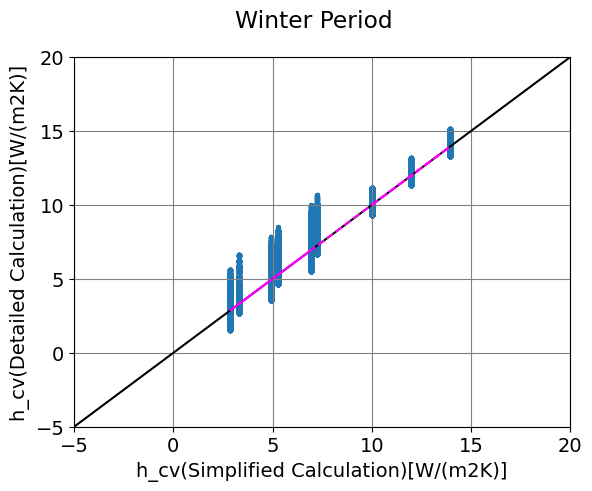

In [62]:
setPltComparison(
    fig_title = "Winter Period",
    x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
    y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
    x_data = df_winter_simple_C["h_cv"],
    y_data = df_winter_detail_C["h_cv"],
    xlim_min = -5.0,
    xlim_max = 20.0,
    ylim_min = -5.0,
    ylim_max = 20.0
)

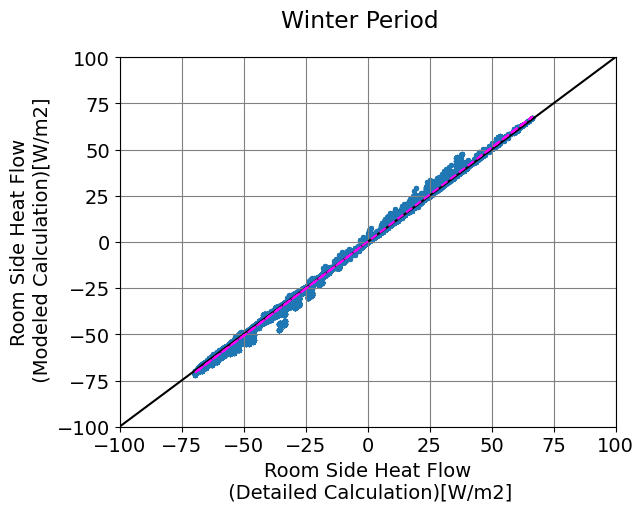

In [63]:
setPltComparison(
    fig_title = "Winter Period",
    x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
    y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
    x_data = df_winter_simple_C["q_room_side"],
    y_data = df_winter_detail_C["q_room_side"],
    xlim_min = -100.0,
    xlim_max = 100.0,
    ylim_min = -100.0,
    ylim_max = 100.0
)

### 全ての厚さ（夏期）

In [64]:
df_summer_simple_C = pd.concat([df_summer_simple_C_005, df_summer_simple_C_0175, df_summer_simple_C_03])
df_summer_detail_C = pd.concat([df_summer_detail_C_005, df_summer_detail_C_0175, df_summer_detail_C_03])

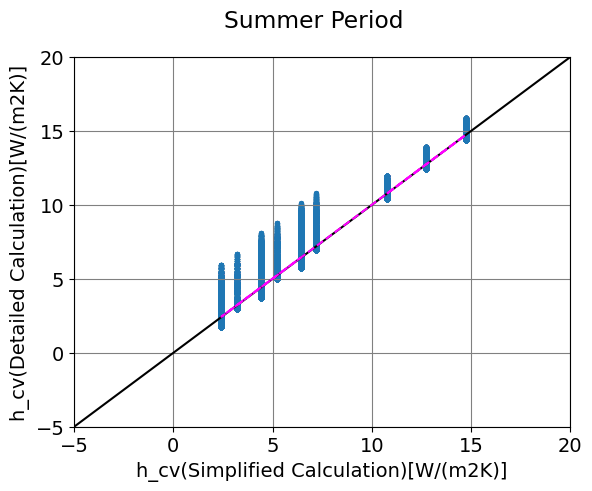

In [65]:
setPltComparison(
    fig_title = "Summer Period",
    x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
    y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
    x_data = df_summer_simple_C["h_cv"],
    y_data = df_summer_detail_C["h_cv"],
    xlim_min = -5.0,
    xlim_max = 20.0,
    ylim_min = -5.0,
    ylim_max = 20.0
)

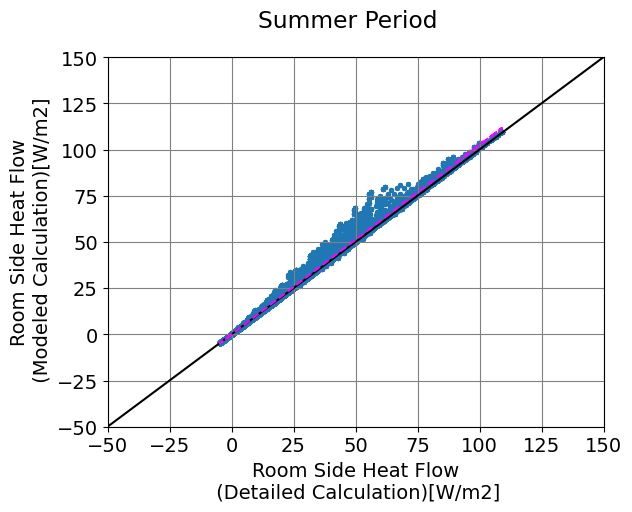

In [66]:
setPltComparison(
    fig_title = "Summer Period",
    x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
    y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
    x_data = df_summer_simple_C["q_room_side"],
    y_data = df_summer_detail_C["q_room_side"],
    xlim_min = -50.0,
    xlim_max = 150.0,
    ylim_min = -50.0,
    ylim_max = 150.0
)

## 放射熱伝達率

### 冬期

In [67]:
df_winter_simple_R = cleansing(
    df=vwp.get_wall_status_data_by_detailed_calculation(
        pms=pms_winter,
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeSimple(a=5.163)
    )    
)
df_winter_detail_R = cleansing(
    df=vwp.get_wall_status_data_by_detailed_calculation(
        pms=pms_winter,
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeDetail()
    )    
)

0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
元データの数： 177147
収束しなかったデータを削除した後のデータ数： 177147
1つでも欠損地NaNがある行を削除した後のデータ数： 157464
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
元データの数： 177147
収束しなかったデータを削除した後のデータ数： 177147
1つでも欠損地NaNがある行を削除した後のデータ数： 157464


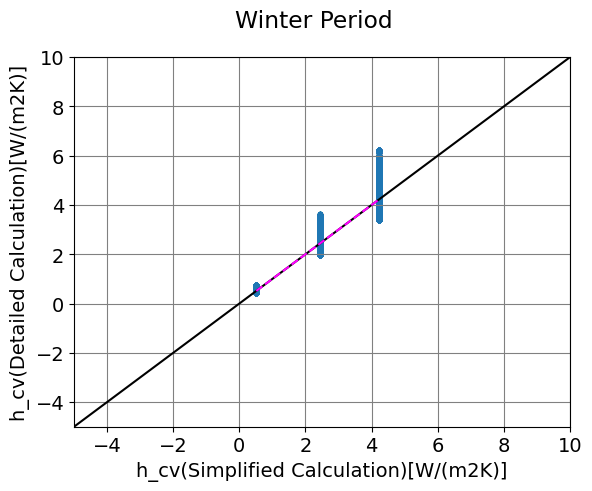

In [68]:
setPltComparison(
    fig_title = "Winter Period",
    x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
    y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
    x_data = df_winter_simple_R["h_rv"],
    y_data = df_winter_detail_R["h_rv"],
    xlim_min = -5.0,
    xlim_max = 10.0,
    ylim_min = -5.0,
    ylim_max = 10.0
)

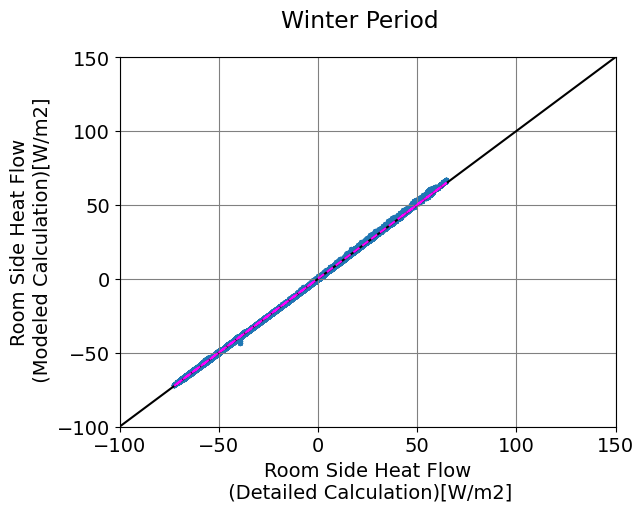

In [69]:
setPltComparison(
       fig_title = "Winter Period",
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_winter_simple_R["q_room_side"],
       y_data = df_winter_detail_R["q_room_side"],
       xlim_min = -100.0,
       xlim_max = 150.0,
       ylim_min = -100.0,
       ylim_max = 150.0
      )

### 夏期

In [70]:
df_summer_simple_R = cleansing(
    df=vwp.get_wall_status_data_by_detailed_calculation(
        pms=pms_summer,
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeSimple(a=6.688)
    )    
)
df_summer_detail_R = cleansing(
    df=vwp.get_wall_status_data_by_detailed_calculation(
        pms=pms_summer,
        hcv_mode=HCVModeDetail(),
        hrv_mode=HRVModeDetail()
    )    
)

0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
元データの数： 177147
収束しなかったデータを削除した後のデータ数： 177147
1つでも欠損地NaNがある行を削除した後のデータ数： 177147
0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
140000
150000
160000
170000
元データの数： 177147
収束しなかったデータを削除した後のデータ数： 177147
1つでも欠損地NaNがある行を削除した後のデータ数： 177147


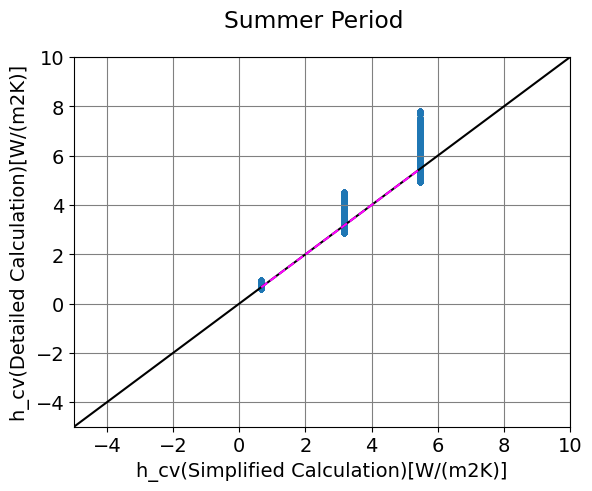

In [71]:
setPltComparison(
    fig_title = "Summer Period",
    x_label = "h_cv(Simplified Calculation)[W/(m2K)]",
    y_label = "h_cv(Detailed Calculation)[W/(m2K)]", 
    x_data = df_summer_simple_R["h_rv"],
    y_data = df_summer_detail_R["h_rv"],
    xlim_min = -5.0,
    xlim_max = 10.0,
    ylim_min = -5.0,
    ylim_max = 10.0
)

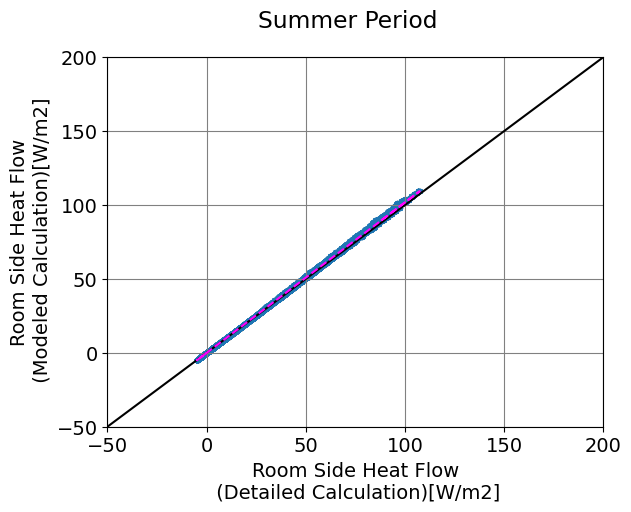

In [72]:
setPltComparison(
       fig_title = "Summer Period",
       x_label = "Room Side Heat Flow\n (Detailed Calculation)[W/m2]",
       y_label = "Room Side Heat Flow\n (Modeled Calculation)[W/m2]",
       x_data = df_summer_simple_R["q_room_side"],
       y_data = df_summer_detail_R["q_room_side"],
       xlim_min = -50.0,
       xlim_max = 200.0,
       ylim_min = -50.0,
       ylim_max = 200.0
      )